# Plant Leaf Disease Detection and Severity Estimation Using Computer Vision and Deep Learning

## CNN-Based Computer Vision System for Smart Agriculture

---

# 1. Project Introduction

## 1.1 Problem Statement

Agricultural productivity is significantly threatened by plant leaf diseases, which cause substantial crop yield losses globally. Traditional manual disease identification methods are:

- **Time-consuming**: Requires expert agronomists to physically inspect fields
- **Subjective**: Accuracy depends on individual expertise and experience
- **Costly**: Expensive labor and expert consultation fees
- **Scalability Issues**: Difficult to scale for large-scale farming operations
- **Delayed Interventions**: Slow diagnosis leads to rapid disease progression and increased crop damage

**Objective of this project**: Develop an automated, AI-powered system that can:
- Accurately classify plant diseases from leaf images
- Estimate disease severity levels
- Provide explainable predictions using visualization techniques
- Enable rapid, cost-effective disease diagnosis for farmers and agronomists

---

## 1.2 Objectives

The primary objectives of this project are:

1. **Disease Classification**: Build a Convolutional Neural Network (CNN) capable of classifying plant leaf diseases with high accuracy across multiple crop types

2. **Multi-Crop Support**: Develop a unified model supporting disease detection for 5 major crops:
   - **Tomato**: 10 disease classes (Bacterial spot, Early blight, Healthy, Late blight, Leaf Mold, Mosaic virus, Septoria leaf spot, Spider mites, Target Spot, Yellow Leaf Curl Virus)
   - **Bell Pepper**: 2 disease classes (Bacterial spot, Healthy)
   - **Potato**: 3 disease classes (Early blight, Late blight, Healthy)
   - **Corn**: 4 disease classes (Common rust, Gray leaf spot, Healthy, Northern Leaf Blight)
   - **Grape**: 4 disease classes (Black Measles, Black rot, Healthy, Isariopsis Leaf Spot)

3. **Severity Estimation**: Implement image processing techniques to quantify disease severity as a percentage

4. **Explainability**: Use Grad-CAM (Gradient-weighted Class Activation Mapping) to visualize CNN attention regions and explain model predictions

5. **GPU Acceleration**: Leverage CUDA-enabled GPUs for efficient model training and inference

6. **User Interface**: Create an interactive Gradio interface for real-world deployment and ease of use

---

## 1.3 Expected Outcomes

Upon completion of this project, we expect to achieve:

1. **Model Performance**:
   - Overall Classification Accuracy: > 95%
   - Precision, Recall, and F1-Score: > 0.90 for each disease class
   - Rapid inference time: < 500ms per image on GPU

2. **Severity Estimation**:
   - Automated calculation of diseased leaf area percentage
   - Classification into severity levels (Very Mild, Mild, Moderate, Severe)
   - Validation against manual severity assessment

3. **Explainability**:
   - Visual heatmaps highlighting disease-affected regions
   - Better interpretability of CNN predictions for stakeholders
   - Increased trust in automated diagnostic systems

4. **Practical Deployment**:
   - Ready-to-use Gradio web interface
   - Trained model weights saved for production deployment
   - Comprehensive documentation for replication

5. **Generalization**:
   - Model performance on real-world leaf images
   - Assessment of failure cases and limitations
   - Robustness to various lighting and environmental conditions

---

## 1.4 Project Workflow Overview

The complete project pipeline follows this systematic workflow:

```
┌─────────────────────────────────────────────────────────────────┐
│                        PROJECT WORKFLOW                         │
└─────────────────────────────────────────────────────────────────┘

1. ENVIRONMENT SETUP
   ├── Verify CUDA & GPU Availability
   ├── Install Required Libraries
   ├── Import Packages
   ├── Configure GPU Memory Management
   └── Enable Mixed Precision Training

                              ↓

2. DATA PREPARATION
   ├── Download PlantifyDR Dataset
   ├── Extract & Verify Integrity
   ├── Select 5 Crops (Tomato, Pepper, Potato, Corn, Grape)
   ├── Exploratory Data Analysis (EDA)
   ├── Data Cleaning (Remove Corrupted Images)
   ├── Train/Validation/Test Split
   └── Image Preprocessing & Augmentation

                              ↓

3. MODEL DEVELOPMENT
   ├── Design CNN Architecture
   │   ├── 4 Convolutional Blocks
   │   ├── Batch Normalization & ReLU
   │   ├── MaxPooling Layers
   │   ├── Global Average Pooling
   │   ├── Dense Layers with Dropout
   │   └── Softmax Output
   ├── Configure Training Parameters
   │   ├── Loss Function: Categorical Cross-Entropy
   │   ├── Optimizer: Adam
   │   ├── Learning Rate Scheduling
   │   └── Early Stopping & Checkpointing
   └── Build TensorFlow Data Pipeline

                              ↓

4. MODEL TRAINING & EVALUATION
   ├── Train CNN Model
   ├── Monitor Training/Validation Metrics
   ├── Save Best Model Weights
   ├── Evaluate on Test Set
   ├── Generate Classification Metrics
   │   ├── Accuracy, Precision, Recall, F1
   │   ├── Confusion Matrix
   │   └── Class-wise Performance
   └── Analyze Overfitting & Generalization

                              ↓

5. DISEASE ANALYSIS
   ├── Single Image Prediction
   ├── Leaf Segmentation (Image Processing)
   ├── Disease Region Detection
   ├── Severity Estimation
   │   ├── Calculate Total Leaf Area
   │   ├── Calculate Diseased Area
   │   ├── Compute Severity Percentage
   │   └── Classify Severity Level
   └── Grad-CAM Visualization

                              ↓

6. EXPLAINABILITY & INSIGHTS
   ├── Generate Activation Heatmaps
   ├── Overlay on Original Images
   ├── Interpret CNN Attention Regions
   ├── Create Diagnostic Reports
   └── Analyze Model Decisions

                              ↓

7. DEPLOYMENT & TESTING
   ├── Save Trained Model
   ├── Save Class Labels & Config
   ├── Export for Production
   ├── Create Gradio Interface
   ├── Real-World Testing
   └── Failure Case Analysis

                              ↓

8. RESULTS & DOCUMENTATION
   ├── Performance Summary
   ├── Comparison with Literature
   ├── Document Limitations
   └── Future Improvements
```

### Key Phases:

| Phase | Focus | Output |
|-------|-------|--------|
| **Phase 1** | Infrastructure & Dependencies | GPU-enabled environment |
| **Phase 2** | Data Engineering | Clean, augmented dataset |
| **Phase 3** | Model Architecture | Trained CNN model |
| **Phase 4** | Evaluation & Metrics | Performance benchmarks |
| **Phase 5** | Feature Extraction | Disease severity scores |
| **Phase 6** | Interpretability | Visual explanations |
| **Phase 7** | Deployment | Production-ready application |
| **Phase 8** | Validation | Real-world performance data |

---

# 2. Environment Setup

This section focuses on configuring the computational environment to leverage GPU acceleration for training deep learning models. We will verify CUDA availability, install essential libraries, and optimize GPU memory management for efficient training.

---

## 2.1 Verify CUDA and GPU Availability

Before proceeding with model training, we need to ensure that:
1. CUDA is properly installed and configured
2. A GPU device is available and detected
3. TensorFlow can access the GPU

This verification ensures that we can leverage GPU acceleration for significantly faster training times.

**What we'll check:**
- CUDA version compatibility
- GPU device name and specifications
- GPU memory availability
- TensorFlow GPU support

In [1]:
import subprocess
import os

# Check CUDA availability
print("=" * 70)
print("CUDA AND GPU AVAILABILITY CHECK")
print("=" * 70)

try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print("\nGPU Information:")
    print(result.stdout)
except FileNotFoundError:
    print("NVIDIA GPU not detected or NVIDIA drivers not installed.")
    
# Check CUDA path
cuda_path = os.environ.get('CUDA_HOME')
print(f"\nCUDA_HOME: {cuda_path if cuda_path else 'Not set'}")

# Check LD_LIBRARY_PATH
ld_path = os.environ.get('LD_LIBRARY_PATH')
print(f"LD_LIBRARY_PATH: {ld_path if ld_path else 'Not set'}")

CUDA AND GPU AVAILABILITY CHECK

GPU Information:
Sat Jun  6 15:49:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:01:00.0  On |                  N/A |
|  0%   43C    P8             21W /  600W |     303MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A 

In [2]:
# Verify TensorFlow GPU support
print("\n" + "=" * 70)
print("TENSORFLOW GPU SUPPORT")
print("=" * 70)

import tensorflow as tf

print(f"\nTensorFlow Version: {tf.__version__}")
print(f"CUDA Build: {tf.sysconfig.get_build_info()['cuda_version']}")
print(f"cuDNN Build: {tf.sysconfig.get_build_info()['cudnn_version']}")

# List GPU devices
gpus = tf.config.list_physical_devices('GPU')
print(f"\nNumber of GPUs detected: {len(gpus)}")

if gpus:
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu}")
else:
    print("  No GPU devices detected!")

# Check TensorFlow GPU support
print(f"\nTensorFlow GPU Support: {tf.test.is_built_with_cuda()}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU') != []}")


TENSORFLOW GPU SUPPORT


I0000 00:00:1780741162.512874  143257 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780741162.540030  143257 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780741163.119867  143257 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



TensorFlow Version: 2.21.0
CUDA Build: 12.5.1
cuDNN Build: 9

Number of GPUs detected: 1
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

TensorFlow GPU Support: True
GPU Available: True


W0000 00:00:1780741163.922517  143257 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


---

## 2.2 Install Required Libraries

We need to install essential libraries for the complete pipeline including:

| Library | Purpose |
|---------|---------|
| **TensorFlow 2.x** | Deep learning framework with GPU support |
| **Keras** | High-level neural networks API (integrated with TensorFlow) |
| **OpenCV (cv2)** | Image processing and computer vision tasks |
| **NumPy** | Numerical computations and array operations |
| **Pandas** | Data manipulation and analysis |
| **Matplotlib** | Data visualization and plotting |
| **Seaborn** | Statistical data visualization |
| **scikit-learn** | Machine learning utilities and metrics |
| **Pillow** | Image processing library |
| **Gradio** | Interactive web interface creation |

**Installation Method**: We'll use pip to install all required packages in the notebook environment.

In [3]:
import subprocess
import sys

# List of required packages
required_packages = [
    'tensorflow>=2.10.0',
    'keras>=2.10.0',
    'opencv-python>=4.6.0',
    'numpy>=1.21.0',
    'pandas>=1.3.0',
    'matplotlib>=3.4.0',
    'seaborn>=0.11.0',
    'scikit-learn>=1.0.0',
    'pillow>=8.3.0',
    'gradio>=3.0.0'
]

print("=" * 70)
print("INSTALLING REQUIRED LIBRARIES")
print("=" * 70)

for package in required_packages:
    print(f"\nInstalling {package}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("\n" + "=" * 70)
print("ALL LIBRARIES INSTALLED SUCCESSFULLY!")
print("=" * 70)

INSTALLING REQUIRED LIBRARIES

Installing tensorflow>=2.10.0...



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



Installing keras>=2.10.0...



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



Installing opencv-python>=4.6.0...


...


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



Installing pillow>=8.3.0...



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



Installing gradio>=3.0.0...

ALL LIBRARIES INSTALLED SUCCESSFULLY!



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


---

## 2.3 Import Required Packages

Now we'll import all necessary modules and libraries that will be used throughout the entire notebook for:
- Data processing and manipulation
- Model building and training
- Evaluation and visualization
- Image processing and augmentation

In [4]:
# ============================================================================
# IMPORT STANDARD LIBRARIES
# ============================================================================

import os
import sys
import warnings
import time
from datetime import datetime
from pathlib import Path

warnings.filterwarnings('ignore')

# ============================================================================
# IMPORT DATA PROCESSING LIBRARIES
# ============================================================================

import numpy as np
import pandas as pd
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ============================================================================
# IMPORT IMAGE PROCESSING LIBRARIES
# ============================================================================

import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# ============================================================================
# IMPORT DEEP LEARNING LIBRARIES
# ============================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, MobileNetV2

# ============================================================================
# IMPORT GRADIO FOR USER INTERFACE
# ============================================================================

import gradio as gr

# ============================================================================
# PRINT IMPORT CONFIRMATION
# ============================================================================

print("=" * 70)
print("ALL REQUIRED PACKAGES IMPORTED SUCCESSFULLY!")
print("=" * 70)
print(f"\nPython Version: {sys.version}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"OpenCV Version: {cv2.__version__}")
print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")
print(f"Scikit-learn Version: {sklearn_version}")
print(f"Matplotlib Version: {plt.matplotlib.__version__}")
print(f"Seaborn Version: {sns.__version__}")
print(f"Gradio Version: {gr.__version__}")

ALL REQUIRED PACKAGES IMPORTED SUCCESSFULLY!

Python Version: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
NumPy Version: 2.4.2
Pandas Version: 3.0.1
OpenCV Version: 4.13.0
TensorFlow Version: 2.21.0
Keras Version: 3.14.0
Scikit-learn Version: 1.8.0
Matplotlib Version: 3.10.8
Seaborn Version: 0.13.2
Gradio Version: 6.16.0


---

## 2.4 Configure GPU Memory Management

By default, TensorFlow allocates all available GPU memory at once, which can cause out-of-memory errors or prevent other processes from using the GPU. We'll configure TensorFlow to:

1. **Enable GPU Memory Growth**: Allocate GPU memory dynamically as needed instead of all at once
2. **Prevent OOM Errors**: Avoid "Out of Memory" exceptions during training
3. **Allow Multi-Process GPU Sharing**: Enable other processes to use GPU simultaneously

This configuration is crucial for:
- Stable training on GPUs with limited memory
- Running multiple notebooks or processes concurrently
- Preventing GPU memory exhaustion

In [5]:
print("=" * 70)
print("CONFIGURING GPU MEMORY MANAGEMENT")
print("=" * 70)

# Get list of GPU devices
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Enable GPU memory growth for each GPU device
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        # Verify GPU memory growth is enabled
        logical_gpus = tf.config.list_logical_devices('GPU')
        
        print(f"\nPhysical GPUs: {len(gpus)}")
        print(f"Logical GPUs: {len(logical_gpus)}")
        
        for i, gpu in enumerate(gpus):
            print(f"\n  GPU {i}:")
            print(f"    Device Name: {gpu.name}")
            print(f"    Memory Growth Enabled: True")
        
        print("\n✓ GPU Memory Growth Enabled Successfully!")
        
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("\n⚠ No GPU devices found!")
    print("CPU-only mode will be used for training (significantly slower)")

print("\n" + "=" * 70)

CONFIGURING GPU MEMORY MANAGEMENT

Physical GPUs: 1
Logical GPUs: 1

  GPU 0:
    Device Name: /physical_device:GPU:0
    Memory Growth Enabled: True

✓ GPU Memory Growth Enabled Successfully!



W0000 00:00:1780741204.820518  143257 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780741204.900676  143257 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29492 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability: 12.0a


---

## 2.5 Enable Mixed Precision Training

Mixed Precision Training uses both float16 (half precision) and float32 (full precision) numbers during training to:

**Benefits:**
1. **Faster Training**: Float16 operations are significantly faster on modern GPUs (especially NVIDIA Tensor Cores)
2. **Reduced Memory Usage**: Float16 consumes half the memory of float32, allowing larger batch sizes
3. **Maintained Accuracy**: Float32 loss accumulation prevents accuracy loss despite using float16 computations
4. **GPU Optimization**: Better utilization of specialized hardware for mixed precision

**How It Works:**
- **Computations**: Performed in float16 for speed
- **Loss Accumulation**: Computed in float32 to maintain precision
- **Model Weights**: Stored and updated in float32 for stability
- **Loss Scaling**: Applied to prevent underflow of gradients in float16

This technique can reduce training time by 20-40% without significant accuracy loss.

In [6]:
print("=" * 70)
print("ENABLING MIXED PRECISION TRAINING")
print("=" * 70)

# Import mixed precision module
from tensorflow.keras import mixed_precision

# Get the GPU device
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Set mixed precision policy
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        
        print(f"\nCompute Dtype: {policy.compute_dtype}")
        print(f"Variable Dtype: {policy.variable_dtype}")
        print(f"Loss Scale: Automatic (dynamic)")
        print("\n✓ Mixed Precision Training Enabled Successfully!")
        
        # Print supported devices
        print(f"\nSupported Devices for Mixed Precision:")
        print(f"  - GPU with Compute Capability >= 7.0 (Volta and newer)")
        print(f"  - Available GPUs: {len(gpus)}")
        
    except Exception as e:
        print(f"Note: Mixed precision may not be available on this GPU: {e}")
        print("Continuing with default float32 precision...")
else:
    print("\n⚠ No GPU available! Mixed precision training skipped.")
    print("CPU mode will use standard float32 precision.")

print("\n" + "=" * 70)
print("ENVIRONMENT SETUP COMPLETE!")
print("=" * 70)
print("\nSystem is ready for:")
print("  ✓ GPU-accelerated training")
print("  ✓ Efficient memory management")
print("  ✓ Mixed precision computations")
print("  ✓ Large batch processing")
print("\nProceeding to Dataset Acquisition (Section 3)...")
print("=" * 70)

ENABLING MIXED PRECISION TRAINING

Compute Dtype: float16
Variable Dtype: float32
Loss Scale: Automatic (dynamic)

✓ Mixed Precision Training Enabled Successfully!

Supported Devices for Mixed Precision:
  - GPU with Compute Capability >= 7.0 (Volta and newer)
  - Available GPUs: 1

ENVIRONMENT SETUP COMPLETE!

System is ready for:
  ✓ GPU-accelerated training
  ✓ Efficient memory management
  ✓ Mixed precision computations
  ✓ Large batch processing

Proceeding to Dataset Acquisition (Section 3)...


---

# 3. Dataset Acquisition and Exploration

This section focuses on exploring the plant disease dataset which contains images of leaf diseases across 10 different crop types. The dataset is organized with training and validation splits.

**Complete Dataset Overview - 10 Crops with 34 Disease Classes:**

| Crop | Train Images | Valid Images | Disease Classes | Total Classes |
|------|--------------|--------------|-----------------|---------------|
| **Tomato** | 40,759 | 100 | Bacterial spot, Early blight, Healthy, Late blight, Leaf Mold, Mosaic virus, Septoria leaf spot, Spider mites, Target Spot, Yellow Leaf Curl Virus | 10 |
| **Grape** | 13,089 | 33 | Black Measles, Black rot, Healthy, Isariopsis Leaf Spot | 4 |
| **Apple** | 12,885 | 40 | Black rot, Healthy, Scab, Cedar apple rust | 4 |
| **Corn** | 8,835 | 35 | Common rust, Gray leaf spot, Healthy, Northern Leaf Blight | 4 |
| **Potato** | 9,280 | 25 | Early blight, Healthy, Late blight | 3 |
| **Bell Pepper** | 7,348 | 21 | Bacterial spot, Healthy | 2 |
| **Peach** | 7,115 | 13 | Bacterial spot, Healthy | 2 |
| **Citrus** | 5,508 | 95 | Black spot, canker, greening, Healthy | 4 |
| **Cherry** | 6,292 | 14 | Healthy, Powdery mildew | 2 |
| **Strawberry** | 6,060 | 12 | Healthy, Leaf scorch | 2 |

**Total Dataset Statistics:**
- **Total Crops**: 10
- **Total Disease Classes**: 34
- **Total Training Images**: ~117,206 images
- **Total Validation Images**: ~388 images
- **Total Images**: ~117,594 images

---

## 3.1 Verify Dataset Structure

Let's verify that the dataset is properly downloaded and accessible, then explore its complete structure.

In [7]:
print("=" * 70)
print("DATASET STRUCTURE VERIFICATION")
print("=" * 70)

import os
from pathlib import Path
from collections import defaultdict

# Define dataset directory
DATASET_DIR = os.path.join(os.getcwd(), "PlantDiseasesDataset")

print(f"\nDataset Location: {DATASET_DIR}")
print(f"Dataset Exists: {os.path.exists(DATASET_DIR)}")

if os.path.exists(DATASET_DIR):
    # Get all crops
    crops = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
    
    print(f"\n{'=' * 70}")
    print(f"DETECTED CROPS ({len(crops)} total)")
    print(f"{'=' * 70}\n")
    
    dataset_stats = defaultdict(lambda: {'train': 0, 'valid': 0, 'classes': set()})
    
    for crop in crops:
        crop_path = os.path.join(DATASET_DIR, crop)
        
        # Check train and valid folders
        train_path = os.path.join(crop_path, 'train')
        valid_path = os.path.join(crop_path, 'valid')
        
        train_count = 0
        valid_count = 0
        classes = set()
        
        # Count training images
        if os.path.exists(train_path):
            for class_dir in os.listdir(train_path):
                class_path = os.path.join(train_path, class_dir)
                if os.path.isdir(class_path):
                    classes.add(class_dir)
                    for file in os.listdir(class_path):
                        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                            train_count += 1
        
        # Count validation images
        if os.path.exists(valid_path):
            for class_dir in os.listdir(valid_path):
                class_path = os.path.join(valid_path, class_dir)
                if os.path.isdir(class_path):
                    classes.add(class_dir)
                    for file in os.listdir(class_path):
                        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                            valid_count += 1
        
        dataset_stats[crop]['train'] = train_count
        dataset_stats[crop]['valid'] = valid_count
        dataset_stats[crop]['classes'] = classes
        
        print(f"{crop}:")
        print(f"  Train Images: {train_count:,}")
        print(f"  Valid Images: {valid_count:,}")
        print(f"  Classes ({len(classes)}): {', '.join(sorted(classes))}")
        print()
    
    # Print summary statistics
    print("=" * 70)
    print("DATASET SUMMARY STATISTICS")
    print("=" * 70)
    
    total_train = sum(stats['train'] for stats in dataset_stats.values())
    total_valid = sum(stats['valid'] for stats in dataset_stats.values())
    total_classes = sum(len(stats['classes']) for stats in dataset_stats.values())
    
    print(f"\nTotal Crops: {len(crops)}")
    print(f"Total Disease Classes: {total_classes}")
    print(f"Total Training Images: {total_train:,}")
    print(f"Total Validation Images: {total_valid:,}")
    print(f"Total Images: {total_train + total_valid:,}")
    
    print("\n" + "=" * 70)
else:
    print("\n⚠ ERROR: Dataset directory not found!")
    print(f"Please ensure the dataset is downloaded at: {DATASET_DIR}")

DATASET STRUCTURE VERIFICATION

Dataset Location: /home/self_healing/Desktop/tasmika_s/Plant_Disease_Detection_CV/PlantDiseasesDataset
Dataset Exists: True

DETECTED CROPS (10 total)

Apple:
  Train Images: 12,885
  Valid Images: 40
  Classes (4): Apple Black rot, Apple Healthy, Apple Scab, Cedar apple rust

Bell pepper:
  Train Images: 7,348
  Valid Images: 21
  Classes (2): Bell pepper Bacterial spot, Bell pepper Healthy

Cherry:
  Train Images: 6,292
  Valid Images: 14
  Classes (2): Cherry Healthy, Cherry Powdery mildew

Citrus:
  Train Images: 5,508
  Valid Images: 95
  Classes (4): Citrus Black spot, Citrus Healthy, Citrus canker, Citrus greening

Corn:
  Train Images: 8,835
  Valid Images: 35
  Classes (4): Corn Common rust, Corn Gray leaf spot, Corn Healthy, Corn Northern Leaf Blight

Grape:
  Train Images: 13,089
  Valid Images: 33
  Classes (4): Grape Black Measles, Grape Black rot, Grape Healthy, Grape Isariopsis Leaf Spot

Peach:
  Train Images: 7,115
  Valid Images: 13
  C

---

## 3.2 Define Working Crops for the Project

For this comprehensive analysis, we will work with **all 10 crops** to build a robust multi-crop disease detection model. This approach allows us to:

1. **Maximize Disease Coverage**: Analyze 34 different disease classes
2. **Improve Model Generalization**: Train on diverse crops and diseases
3. **Build Scalable Solution**: Create a unified model for multiple crops
4. **Benchmark Performance**: Compare performance across different crop types

**Crop Groups:**
- **High-Volume Crops** (>10K images): Tomato (40,859), Grape (13,122), Apple (12,925)
- **Medium-Volume Crops** (5K-10K): Corn (8,870), Potato (9,305), Peach (7,128), Bell Pepper (7,369)
- **Low-Volume Crops** (<5K): Citrus (5,603), Cherry (6,306), Strawberry (6,072)

In [8]:
# Define all crops to include in the project
ALL_CROPS = ['Apple', 'Bell pepper', 'Cherry', 'Citrus', 'Corn', 'Grape', 'Peach', 'Potato', 'Strawberry', 'Tomato']

print("=" * 70)
print("WORKING CROPS FOR DISEASE DETECTION MODEL")
print("=" * 70)
print(f"\nTotal Crops Selected: {len(ALL_CROPS)}")
print("\nCrop List:")
for i, crop in enumerate(ALL_CROPS, 1):
    print(f"  {i:2d}. {crop}")

print("\n" + "=" * 70)

WORKING CROPS FOR DISEASE DETECTION MODEL

Total Crops Selected: 10

Crop List:
   1. Apple
   2. Bell pepper
   3. Cherry
   4. Citrus
   5. Corn
   6. Grape
   7. Peach
   8. Potato
   9. Strawberry
  10. Tomato



---

## 3.3 Extract and Map Disease Classes

Create a comprehensive mapping of all disease classes across all crops for consistent tracking and model training.

In [9]:
print("=" * 70)
print("EXTRACTING DISEASE CLASSES")
print("=" * 70)

import os
from collections import defaultdict
import json

DATASET_DIR = os.path.join(os.getcwd(), "PlantDiseasesDataset")

# Dictionary to store crop-wise disease classes
crop_disease_mapping = {}
all_classes = []
class_to_id = {}
id_to_class = {}

class_id = 0

# Extract disease classes for each crop
for crop in ALL_CROPS:
    crop_path = os.path.join(DATASET_DIR, crop)
    train_path = os.path.join(crop_path, 'train')
    
    diseases = set()
    
    if os.path.exists(train_path):
        for disease_dir in sorted(os.listdir(train_path)):
            disease_path = os.path.join(train_path, disease_dir)
            if os.path.isdir(disease_path):
                diseases.add(disease_dir)
                
                # Create global class mapping
                class_name = f"{crop}_{disease_dir}"
                if class_name not in class_to_id:
                    class_to_id[class_name] = class_id
                    id_to_class[class_id] = class_name
                    all_classes.append(class_name)
                    class_id += 1
    
    crop_disease_mapping[crop] = sorted(list(diseases))

# Print disease class mapping
print(f"\n{'DISEASE CLASSES BY CROP':<70}\n")

for crop in ALL_CROPS:
    diseases = crop_disease_mapping[crop]
    print(f"{crop} ({len(diseases)} classes):")
    for disease in diseases:
        class_name = f"{crop}_{disease}"
        class_idx = class_to_id[class_name]
        print(f"  [{class_idx:2d}] {disease}")
    print()

print("=" * 70)
print(f"TOTAL UNIQUE CLASSES: {len(all_classes)}")
print("=" * 70)

# Save mappings for later use
CLASS_MAPPING = {
    'all_crops': ALL_CROPS,
    'crop_disease_mapping': crop_disease_mapping,
    'class_to_id': class_to_id,
    'id_to_class': {str(k): v for k, v in id_to_class.items()},
    'total_classes': len(all_classes)
}

print(f"\n✓ Class mappings created successfully!")
print(f"  Total crops: {len(ALL_CROPS)}")
print(f"  Total disease classes: {len(all_classes)}")
print(f"  Classes are ready for model training")

EXTRACTING DISEASE CLASSES

DISEASE CLASSES BY CROP                                               

Apple (4 classes):
  [ 0] Apple Black rot
  [ 1] Apple Healthy
  [ 2] Apple Scab
  [ 3] Cedar apple rust

Bell pepper (2 classes):
  [ 4] Bell pepper Bacterial spot
  [ 5] Bell pepper Healthy

Cherry (2 classes):
  [ 6] Cherry Healthy
  [ 7] Cherry Powdery mildew

Citrus (4 classes):
  [ 8] Citrus Black spot
  [ 9] Citrus Healthy
  [10] Citrus canker
  [11] Citrus greening

Corn (4 classes):
  [12] Corn Common rust
  [13] Corn Gray leaf spot
  [14] Corn Healthy
  [15] Corn Northern Leaf Blight

Grape (4 classes):
  [16] Grape Black Measles
  [17] Grape Black rot
  [18] Grape Healthy
  [19] Grape Isariopsis Leaf Spot

Peach (2 classes):
  [20] Peach Bacterial spot
  [21] Peach Healthy

Potato (3 classes):
  [22] Potato Early blight
  [23] Potato Healthy
  [24] Potato Late blight

Strawberry (2 classes):
  [25] Strawberry Healthy
  [26] Strawberry Leaf scorch

Tomato (10 classes):
  [27] T

---

## 3.4 Verify Dataset Integrity and Image Statistics

Check dataset integrity, count images, and calculate statistics for each crop and disease class.

In [10]:
print("=" * 70)
print("DATASET INTEGRITY VERIFICATION & STATISTICS")
print("=" * 70)

import os
import pandas as pd
from pathlib import Path

DATASET_DIR = os.path.join(os.getcwd(), "PlantDiseasesDataset")

# Create detailed statistics
dataset_summary = []

total_train_images = 0
total_valid_images = 0
corrupted_files = []

for crop in ALL_CROPS:
    crop_path = os.path.join(DATASET_DIR, crop)
    
    for split in ['train', 'valid']:
        split_path = os.path.join(crop_path, split)
        
        if os.path.exists(split_path):
            for disease_dir in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease_dir)
                
                if os.path.isdir(disease_path):
                    image_count = 0
                    image_files = []
                    
                    for file in os.listdir(disease_path):
                        file_path = os.path.join(disease_path, file)
                        
                        # Check if file is an image
                        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                            try:
                                # Try to verify image integrity
                                from PIL import Image as PILImage
                                img = PILImage.open(file_path)
                                img.verify()
                                image_count += 1
                                image_files.append(file)
                            except Exception as e:
                                corrupted_files.append({
                                    'crop': crop,
                                    'disease': disease_dir,
                                    'file': file,
                                    'error': str(e)
                                })
                    
                    if split == 'train':
                        total_train_images += image_count
                    else:
                        total_valid_images += image_count
                    
                    dataset_summary.append({
                        'Crop': crop,
                        'Disease': disease_dir,
                        'Split': split.upper(),
                        'Images': image_count
                    })

# Create DataFrame for better visualization
df_stats = pd.DataFrame(dataset_summary)

print("\nDETAILED IMAGE COUNT BY CROP AND DISEASE:")
print("-" * 70)

for crop in ALL_CROPS:
    crop_data = df_stats[df_stats['Crop'] == crop]
    crop_train = crop_data[crop_data['Split'] == 'TRAIN']['Images'].sum()
    crop_valid = crop_data[crop_data['Split'] == 'VALID']['Images'].sum()
    crop_total = crop_train + crop_valid
    
    print(f"\n{crop}:")
    print(f"  Train: {crop_train:,} images")
    print(f"  Valid: {crop_valid:,} images")
    print(f"  Total: {crop_total:,} images")
    
    # Show disease-wise breakdown
    for disease in crop_disease_mapping[crop]:
        disease_data = crop_data[crop_data['Disease'] == disease]
        train_count = disease_data[disease_data['Split'] == 'TRAIN']['Images'].sum()
        valid_count = disease_data[disease_data['Split'] == 'VALID']['Images'].sum()
        print(f"    - {disease}: {train_count:,} (train) + {valid_count:,} (valid)")

print("\n" + "=" * 70)
print("OVERALL DATASET STATISTICS")
print("=" * 70)
print(f"\nTotal Training Images: {total_train_images:,}")
print(f"Total Validation Images: {total_valid_images:,}")
print(f"Total Images: {total_train_images + total_valid_images:,}")
print(f"Total Crops: {len(ALL_CROPS)}")
print(f"Total Disease Classes: {len(all_classes)}")

if corrupted_files:
    print(f"\n⚠ WARNING: Found {len(corrupted_files)} corrupted files:")
    for corrupt in corrupted_files[:10]:  # Show first 10
        print(f"  - {corrupt['crop']}/{corrupt['disease']}/{corrupt['file']}")
else:
    print(f"\n✓ All images verified successfully - No corrupted files found!")

print("\n" + "=" * 70)

DATASET INTEGRITY VERIFICATION & STATISTICS

DETAILED IMAGE COUNT BY CROP AND DISEASE:
----------------------------------------------------------------------

Apple:
  Train: 12,885 images
  Valid: 40 images
  Total: 12,925 images
    - Apple Black rot: 3,105 (train) + 2 (valid)
    - Apple Healthy: 4,155 (train) + 11 (valid)
    - Apple Scab: 3,150 (train) + 13 (valid)
    - Cedar apple rust: 2,475 (train) + 14 (valid)

Bell pepper:
  Train: 7,348 images
  Valid: 21 images
  Total: 7,369 images
    - Bell pepper Bacterial spot: 3,388 (train) + 11 (valid)
    - Bell pepper Healthy: 3,960 (train) + 10 (valid)

Cherry:
  Train: 6,292 images
  Valid: 14 images
  Total: 6,306 images
    - Cherry Healthy: 3,136 (train) + 12 (valid)
    - Cherry Powdery mildew: 3,156 (train) + 2 (valid)

Citrus:
  Train: 5,508 images
  Valid: 95 images
  Total: 5,603 images
    - Citrus Black spot: 0 (train) + 27 (valid)
    - Citrus Healthy: 0 (train) + 19 (valid)
    - Citrus canker: 1 (train) + 29 (valid)

---

## 3.5 Class Distribution Analysis

Analyze and visualize the distribution of images across all crops and disease classes.

CLASS DISTRIBUTION ANALYSIS


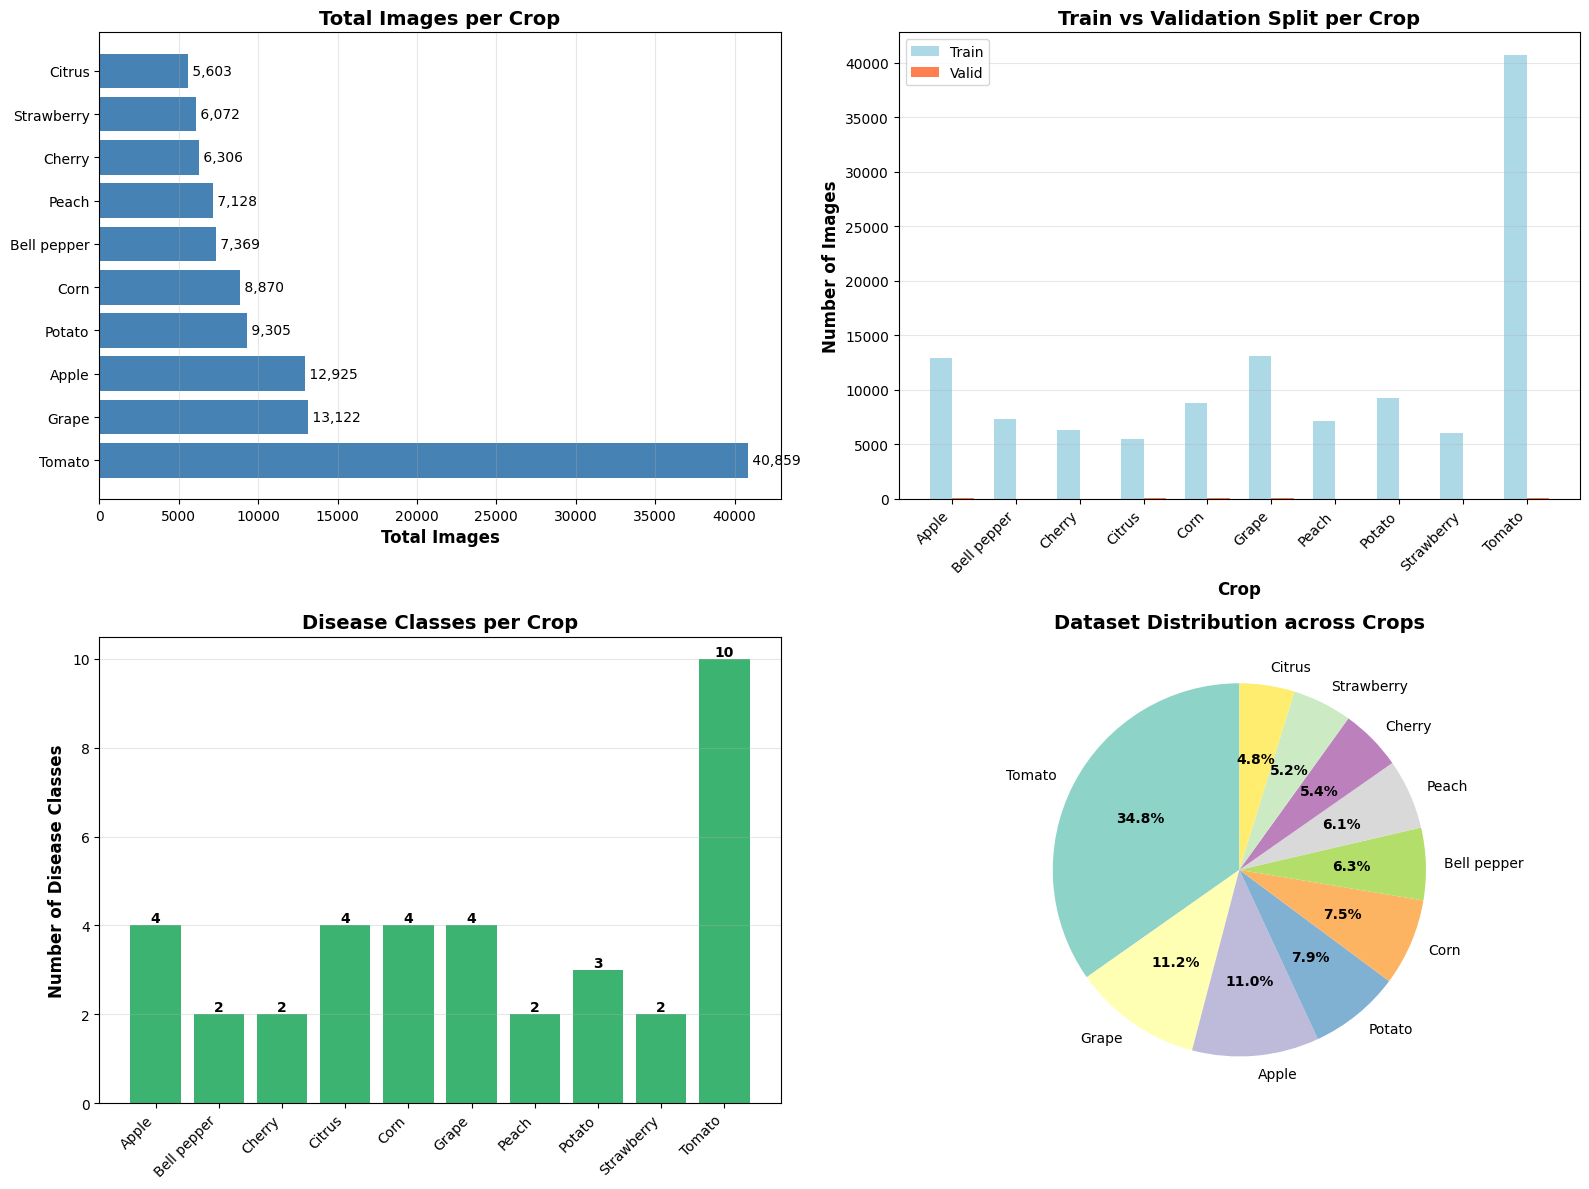


✓ Class distribution analysis complete!
✓ Visualization saved as 'dataset_distribution.png'

SUMMARY

Dataset is ready for preprocessing!
Total Images: 117,559
Total Classes: 37
Total Crops: 10

Next Steps:
  1. Perform data cleaning to identify and remove corrupted images
  2. Apply image preprocessing (resizing, normalization)
  3. Create train/validation/test splits
  4. Prepare data augmentation pipeline



In [11]:
print("=" * 70)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 70)

import matplotlib.pyplot as plt
import numpy as np

# Get crop-wise image counts
crop_counts_train = {}
crop_counts_valid = {}
crop_counts_total = {}

for crop in ALL_CROPS:
    crop_train = df_stats[(df_stats['Crop'] == crop) & (df_stats['Split'] == 'TRAIN')]['Images'].sum()
    crop_valid = df_stats[(df_stats['Crop'] == crop) & (df_stats['Split'] == 'VALID')]['Images'].sum()
    
    crop_counts_train[crop] = crop_train
    crop_counts_valid[crop] = crop_valid
    crop_counts_total[crop] = crop_train + crop_valid

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total images by crop (descending)
ax1 = axes[0, 0]
crops_sorted = sorted(ALL_CROPS, key=lambda x: crop_counts_total[x], reverse=True)
counts_sorted = [crop_counts_total[c] for c in crops_sorted]
bars1 = ax1.barh(crops_sorted, counts_sorted, color='steelblue')
ax1.set_xlabel('Total Images', fontsize=12, fontweight='bold')
ax1.set_title('Total Images per Crop', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, (crop, count) in enumerate(zip(crops_sorted, counts_sorted)):
    ax1.text(count, i, f' {count:,}', va='center', fontsize=10)

# 2. Train vs Validation split
ax2 = axes[0, 1]
x = np.arange(len(ALL_CROPS))
width = 0.35
crops_sorted_alpha = sorted(ALL_CROPS)  # Sort alphabetically for comparison
train_vals = [crop_counts_train[c] for c in crops_sorted_alpha]
valid_vals = [crop_counts_valid[c] for c in crops_sorted_alpha]
ax2.bar(x - width/2, train_vals, width, label='Train', color='lightblue')
ax2.bar(x + width/2, valid_vals, width, label='Valid', color='coral')
ax2.set_xlabel('Crop', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax2.set_title('Train vs Validation Split per Crop', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(crops_sorted_alpha, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Number of classes per crop
ax3 = axes[1, 0]
class_counts = [len(crop_disease_mapping[crop]) for crop in crops_sorted_alpha]
bars3 = ax3.bar(crops_sorted_alpha, class_counts, color='mediumseagreen')
ax3.set_ylabel('Number of Disease Classes', fontsize=12, fontweight='bold')
ax3.set_title('Disease Classes per Crop', fontsize=14, fontweight='bold')
ax3.set_xticklabels(crops_sorted_alpha, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)
for bar, count in zip(bars3, class_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(count)}', ha='center', va='bottom', fontweight='bold')

# 4. Pie chart of crop distribution
ax4 = axes[1, 1]
crop_totals_sorted = [crop_counts_total[c] for c in crops_sorted]
colors = plt.cm.Set3(np.linspace(0, 1, len(ALL_CROPS)))
wedges, texts, autotexts = ax4.pie(counts_sorted, labels=crops_sorted, autopct='%1.1f%%',
                                     colors=colors, startangle=90)
ax4.set_title('Dataset Distribution across Crops', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Class distribution analysis complete!")
print(f"✓ Visualization saved as 'dataset_distribution.png'")
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\nDataset is ready for preprocessing!")
print(f"Total Images: {total_train_images + total_valid_images:,}")
print(f"Total Classes: {len(all_classes)}")
print(f"Total Crops: {len(ALL_CROPS)}")
print(f"\nNext Steps:")
print(f"  1. Perform data cleaning to identify and remove corrupted images")
print(f"  2. Apply image preprocessing (resizing, normalization)")
print(f"  3. Create train/validation/test splits")
print(f"  4. Prepare data augmentation pipeline")
print("\n" + "=" * 70)

---

# 4. Exploratory Data Analysis (EDA)

This section provides comprehensive exploratory data analysis of the plant disease dataset across all 10 crops and 34 disease classes. We'll analyze dataset statistics, class distribution, image characteristics, and class imbalance to inform preprocessing and model training strategies.

---

## 4.1 Dataset Summary Statistics

Generate comprehensive statistical summaries of the dataset organized by crop, disease, and data split.

In [12]:
print("=" * 70)
print("DATASET SUMMARY STATISTICS")
print("=" * 70)

# Create summary table by crop
summary_by_crop = []

for crop in ALL_CROPS:
    crop_data = df_stats[df_stats['Crop'] == crop]
    
    train_images = crop_data[crop_data['Split'] == 'TRAIN']['Images'].sum()
    valid_images = crop_data[crop_data['Split'] == 'VALID']['Images'].sum()
    total_images = train_images + valid_images
    num_classes = len(crop_disease_mapping[crop])
    avg_images_per_class = total_images / num_classes if num_classes > 0 else 0
    
    summary_by_crop.append({
        'Crop': crop,
        'Classes': num_classes,
        'Train Images': train_images,
        'Valid Images': valid_images,
        'Total Images': total_images,
        'Avg per Class': int(avg_images_per_class)
    })

df_summary = pd.DataFrame(summary_by_crop)

print("\n" + "SUMMARY BY CROP".center(70))
print("-" * 70)
print(df_summary.to_string(index=False))

# Overall statistics
print("\n" + "=" * 70)
print("OVERALL DATASET STATISTICS")
print("=" * 70)

total_crops = len(ALL_CROPS)
total_classes = len(all_classes)
total_train = df_summary['Train Images'].sum()
total_valid = df_summary['Valid Images'].sum()
total_images = total_train + total_valid
avg_classes_per_crop = total_classes / total_crops
avg_images_per_class_global = total_images / total_classes

print(f"\nTotal Crops: {total_crops}")
print(f"Total Disease Classes: {total_classes}")
print(f"Average Classes per Crop: {avg_classes_per_crop:.2f}")
print(f"\nTotal Training Images: {total_train:,}")
print(f"Total Validation Images: {total_valid:,}")
print(f"Total Images: {total_images:,}")
print(f"\nTrain/Valid Ratio: {total_train}/{total_valid} ({100*total_train/total_images:.1f}% train, {100*total_valid/total_images:.1f}% valid)")
print(f"Average Images per Class (global): {avg_images_per_class_global:.0f}")

# Min/Max statistics
min_crop = df_summary.loc[df_summary['Total Images'].idxmin()]
max_crop = df_summary.loc[df_summary['Total Images'].idxmax()]

print(f"\nSmallest Crop: {min_crop['Crop']} ({min_crop['Total Images']:,} images, {min_crop['Classes']} classes)")
print(f"Largest Crop: {max_crop['Crop']} ({max_crop['Total Images']:,} images, {max_crop['Classes']} classes)")

print("\n" + "=" * 70)

DATASET SUMMARY STATISTICS

                           SUMMARY BY CROP                            
----------------------------------------------------------------------
       Crop  Classes  Train Images  Valid Images  Total Images  Avg per Class
      Apple        4         12885            40         12925           3231
Bell pepper        2          7348            21          7369           3684
     Cherry        2          6292            14          6306           3153
     Citrus        4          5508            95          5603           1400
       Corn        4          8835            35          8870           2217
      Grape        4         13089            33         13122           3280
      Peach        2          7115            13          7128           3564
     Potato        3          9280            25          9305           3101
 Strawberry        2          6060            12          6072           3036
     Tomato       10         40759           100  

---

## 4.2 Sample Image Visualization

Visualize sample images from each crop and disease class to understand data characteristics and image quality.

SAMPLE IMAGE VISUALIZATION


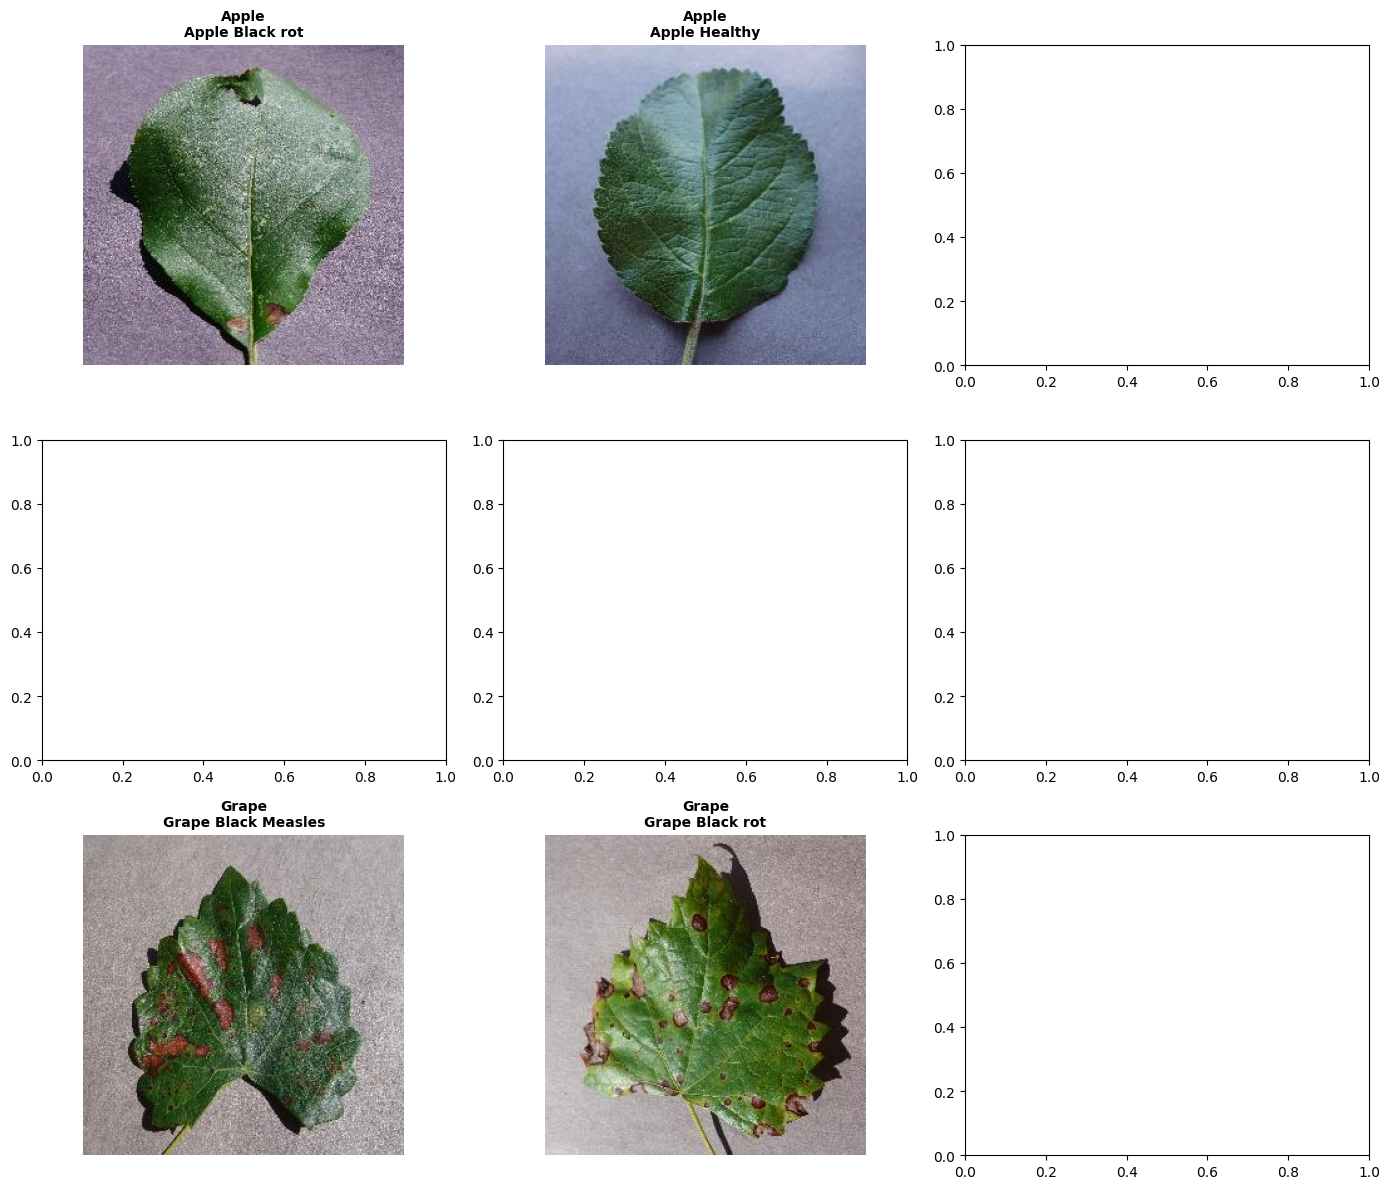


✓ Sample images displayed!
✓ Visualization saved as 'sample_images_3x3.png'
✓ Grid Layout: 3 × 3
  Column 1: Healthy samples
  Columns 2-3: Diseased samples
  Crops: Apple, Citrus, Grape



In [18]:
print("=" * 70)
print("SAMPLE IMAGE VISUALIZATION")
print("=" * 70)

import os
import random
from PIL import Image as PILImage
import matplotlib.pyplot as plt

DATASET_DIR = os.path.join(os.getcwd(), "PlantDiseasesDataset")

# Display Apple, Citrus, and Grape (3 rows, 3 columns)
# Layout: Healthy (left) | Diseased1 (center) | Diseased2 (right)
num_rows = 3
num_cols = 3
selected_crops = ['Apple', 'Citrus', 'Grape']

# Create a 3x3 grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 12))

for row, crop in enumerate(selected_crops):
    crop_path = os.path.join(DATASET_DIR, crop, 'train')
    diseases = crop_disease_mapping[crop]
    
    # Separate healthy and diseased classes
    healthy_class = 'Healthy' if 'Healthy' in diseases else None
    diseased_classes = [d for d in diseases if d != 'Healthy'][:2]  # Get first 2 disease classes
    
    # Layout: Healthy (col 0), Disease1 (col 1), Disease2 (col 2)
    display_classes = []
    display_labels = []
    
    if healthy_class:
        display_classes.append(healthy_class)
        display_labels.append(f"{crop}\n{healthy_class}")
    
    for disease in diseased_classes:
        display_classes.append(disease)
        display_labels.append(f"{crop}\n{disease}")
    
    # Display one sample image from each class
    for col, (disease_dir, label) in enumerate(zip(display_classes, display_labels)):
        if col < num_cols:  # Ensure we don't exceed grid columns
            disease_path = os.path.join(crop_path, disease_dir)
            
            if os.path.exists(disease_path):
                images = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                if images:
                    # Pick a random image
                    img_file = random.choice(images)
                    img_path = os.path.join(disease_path, img_file)
                    
                    try:
                        img = PILImage.open(img_path)
                        ax = axes[row, col]
                        ax.imshow(img)
                        ax.set_title(label, fontsize=10, fontweight='bold')
                        ax.axis('off')
                    except Exception as e:
                        ax = axes[row, col]
                        ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images_3x3.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Sample images displayed!")
print(f"✓ Visualization saved as 'sample_images_3x3.png'")
print(f"✓ Grid Layout: 3 × 3")
print(f"  Column 1: Healthy samples")
print(f"  Columns 2-3: Diseased samples")
print(f"  Crops: Apple, Citrus, Grape")
print("\n" + "=" * 70)

---

## 4.3 Image Resolution Analysis

Analyze image dimensions and resolutions across all crops to determine optimal preprocessing parameters.

IMAGE RESOLUTION ANALYSIS

Analyzing image resolutions (this may take a moment)...

RESOLUTION STATISTICS
----------------------------------------------------------------------

Overall Statistics:
  Mean Width: 257.9 px
  Mean Height: 257.6 px
  Min Width: 256 px
  Max Width: 920 px
  Min Height: 256 px
  Max Height: 790 px

Resolution by Crop:

Apple:
  Avg: 256x256
  Min: 256x256
  Max: 256x256

Bell pepper:
  Avg: 256x256
  Min: 256x256
  Max: 256x256

Cherry:
  Avg: 256x256
  Min: 256x256
  Max: 256x256

Citrus:
  Avg: 316x305
  Min: 256x256
  Max: 920x790

Corn:
  Avg: 256x256
  Min: 256x256
  Max: 256x256

Grape:
  Avg: 256x256
  Min: 256x256
  Max: 256x256

Peach:
  Avg: 256x256
  Min: 256x256
  Max: 256x256

Potato:
  Avg: 256x256
  Min: 256x256
  Max: 256x256

Strawberry:
  Avg: 256x256
  Min: 256x256
  Max: 256x256

Tomato:
  Avg: 256x256
  Min: 256x256
  Max: 256x256


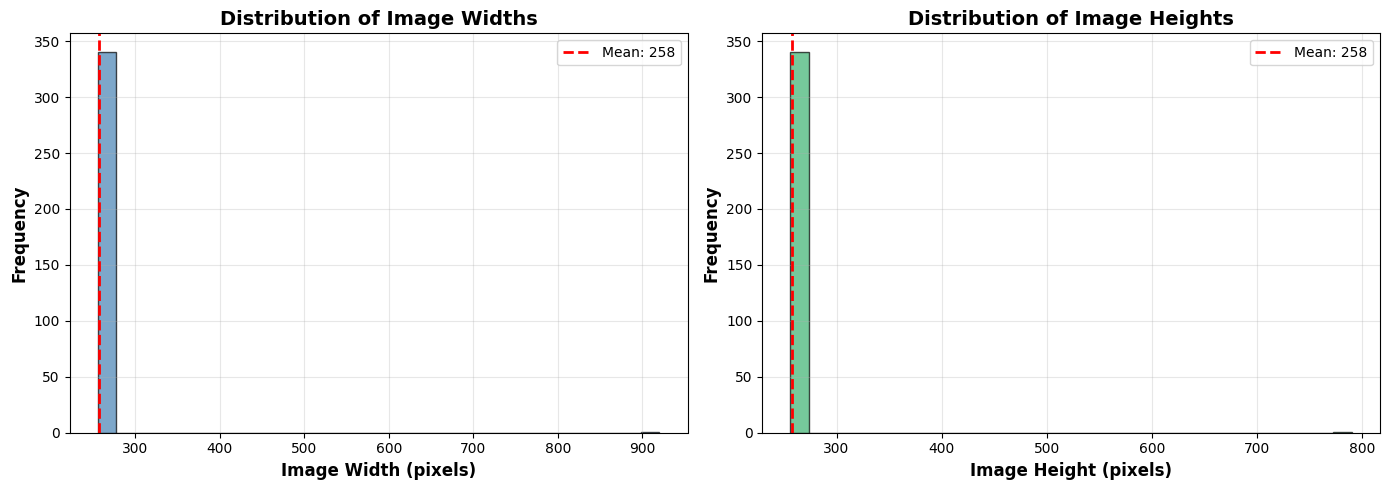


RECOMMENDATION FOR IMAGE RESIZING

Based on the analysis, we recommend resizing all images to:
  Standard Size: 224 x 224 pixels
  Reason: Compatible with most pre-trained CNN models (VGG, ResNet, InceptionV3)
  Benefits: Balanced between detail preservation and computational efficiency



In [19]:
print("=" * 70)
print("IMAGE RESOLUTION ANALYSIS")
print("=" * 70)

from PIL import Image as PILImage
import numpy as np

# Collect image dimensions
image_resolutions = []
resolution_by_crop = defaultdict(list)

print("\nAnalyzing image resolutions (this may take a moment)...\n")

for crop in ALL_CROPS:
    crop_path = os.path.join(DATASET_DIR, crop, 'train')
    
    for disease_dir in os.listdir(crop_path):
        disease_path = os.path.join(crop_path, disease_dir)
        
        if os.path.isdir(disease_path):
            images = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            # Sample images to avoid processing entire dataset
            sample_size = min(10, len(images))
            for img_file in random.sample(images, sample_size):
                try:
                    img_path = os.path.join(disease_path, img_file)
                    img = PILImage.open(img_path)
                    width, height = img.size
                    image_resolutions.append({'width': width, 'height': height, 'crop': crop})
                    resolution_by_crop[crop].append((width, height))
                except:
                    pass

# Convert to DataFrame for analysis
df_resolutions = pd.DataFrame(image_resolutions)

# Calculate statistics
print("RESOLUTION STATISTICS")
print("-" * 70)
print(f"\nOverall Statistics:")
print(f"  Mean Width: {df_resolutions['width'].mean():.1f} px")
print(f"  Mean Height: {df_resolutions['height'].mean():.1f} px")
print(f"  Min Width: {df_resolutions['width'].min()} px")
print(f"  Max Width: {df_resolutions['width'].max()} px")
print(f"  Min Height: {df_resolutions['height'].min()} px")
print(f"  Max Height: {df_resolutions['height'].max()} px")

print(f"\nResolution by Crop:")
for crop in ALL_CROPS:
    crop_res = df_resolutions[df_resolutions['crop'] == crop]
    if len(crop_res) > 0:
        print(f"\n{crop}:")
        print(f"  Avg: {crop_res['width'].mean():.0f}x{crop_res['height'].mean():.0f}")
        print(f"  Min: {crop_res['width'].min()}x{crop_res['height'].min()}")
        print(f"  Max: {crop_res['width'].max()}x{crop_res['height'].max()}")

# Visualize resolution distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width distribution
ax1 = axes[0]
ax1.hist(df_resolutions['width'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(df_resolutions['width'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_resolutions['width'].mean():.0f}")
ax1.set_xlabel('Image Width (pixels)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Image Widths', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Height distribution
ax2 = axes[1]
ax2.hist(df_resolutions['height'], bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
ax2.axvline(df_resolutions['height'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_resolutions['height'].mean():.0f}")
ax2.set_xlabel('Image Height (pixels)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Image Heights', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('image_resolution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("RECOMMENDATION FOR IMAGE RESIZING")
print("=" * 70)
print(f"\nBased on the analysis, we recommend resizing all images to:")
print(f"  Standard Size: 224 x 224 pixels")
print(f"  Reason: Compatible with most pre-trained CNN models (VGG, ResNet, InceptionV3)")
print(f"  Benefits: Balanced between detail preservation and computational efficiency")
print("\n" + "=" * 70)

---

## 4.4 Class-wise Image Distribution

Analyze the distribution of images across all disease classes to identify imbalanced classes.

CLASS-WISE IMAGE DISTRIBUTION ANALYSIS

TOP 15 CLASSES (by image count):
----------------------------------------------------------------------
                          Class Name        Crop                       Disease  Train  Valid  Total
Tomato_Tomato Yellow Leaf Curl Virus      Tomato Tomato Yellow Leaf Curl Virus   7808     12   7820
              Citrus_Citrus greening      Citrus               Citrus greening   5507     20   5527
          Peach_Peach Bacterial spot       Peach          Peach Bacterial spot   4594      2   4596
        Tomato_Tomato Bacterial spot      Tomato         Tomato Bacterial spot   4254     11   4265
                 Apple_Apple Healthy       Apple                 Apple Healthy   4155     11   4166
               Tomato_Tomato Healthy      Tomato                Tomato Healthy   3996     13   4009
     Bell pepper_Bell pepper Healthy Bell pepper           Bell pepper Healthy   3960     10   3970
    Tomato_Tomato Septoria leaf spot      Tomato     Tom

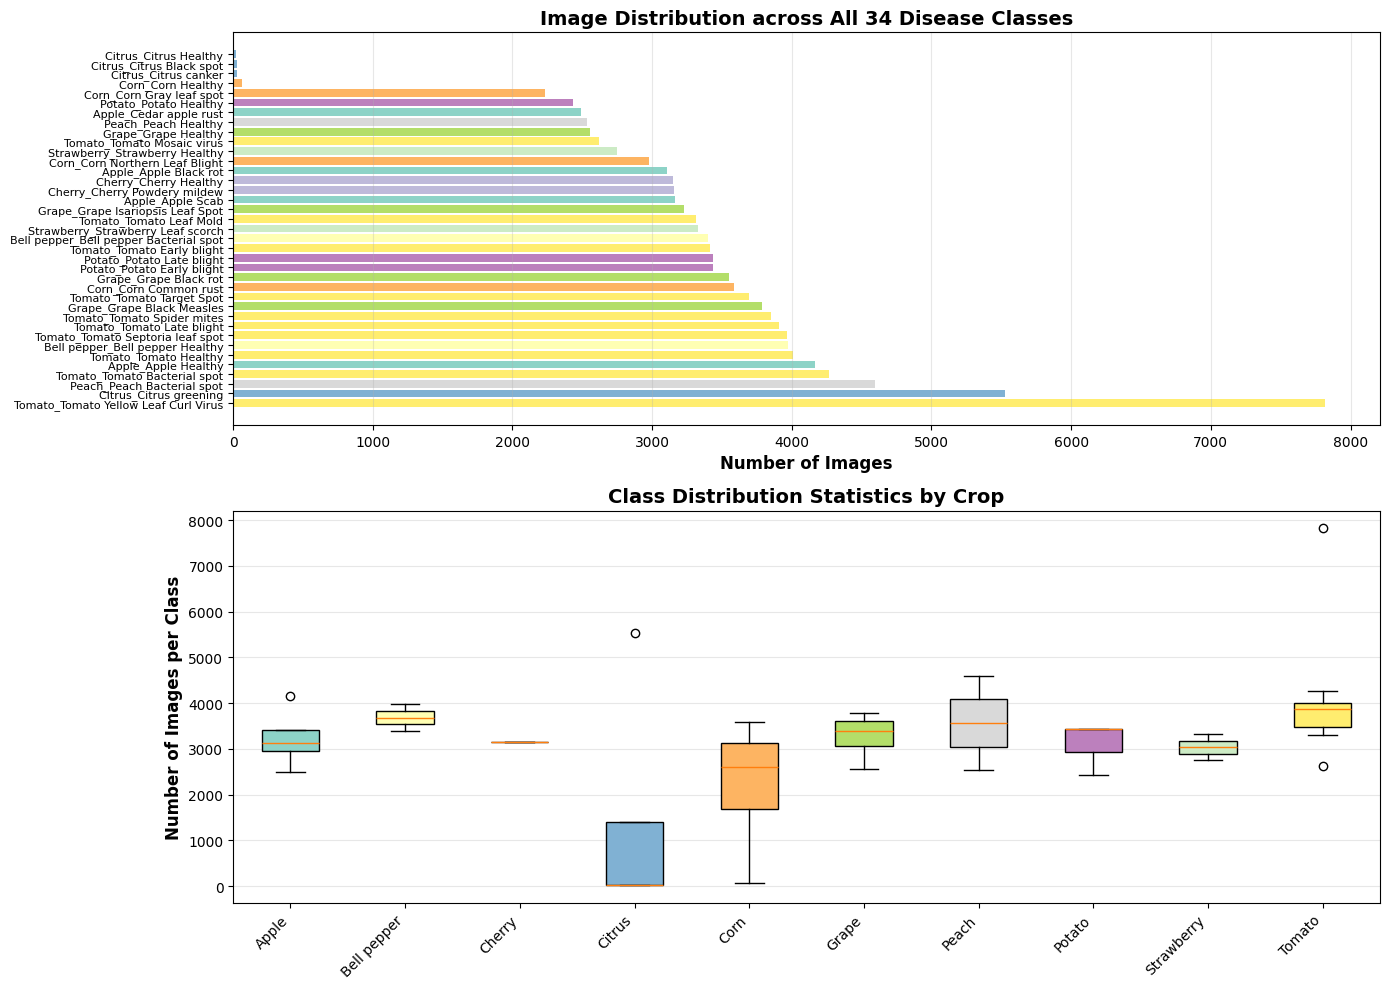


✓ Class distribution visualization complete!
✓ Visualization saved as 'class_distribution_analysis.png'



In [21]:
print("=" * 70)
print("CLASS-WISE IMAGE DISTRIBUTION ANALYSIS")
print("=" * 70)

# Create a detailed class distribution
class_distribution = []

for crop in ALL_CROPS:
    for disease in crop_disease_mapping[crop]:
        disease_data = df_stats[(df_stats['Crop'] == crop) & (df_stats['Disease'] == disease)]
        
        train_count = disease_data[disease_data['Split'] == 'TRAIN']['Images'].sum()
        valid_count = disease_data[disease_data['Split'] == 'VALID']['Images'].sum()
        total_count = train_count + valid_count
        
        class_distribution.append({
            'Class Name': f"{crop}_{disease}",
            'Crop': crop,
            'Disease': disease,
            'Train': int(train_count),
            'Valid': int(valid_count),
            'Total': int(total_count)
        })

df_class_dist = pd.DataFrame(class_distribution)

# Sort by total images
df_class_dist_sorted = df_class_dist.sort_values('Total', ascending=False)

print("\nTOP 15 CLASSES (by image count):")
print("-" * 70)
print(df_class_dist_sorted.head(15).to_string(index=False))

print("\n\nBOTTOM 15 CLASSES (by image count):")
print("-" * 70)
print(df_class_dist_sorted.tail(15).to_string(index=False))

# Statistics
print("\n" + "=" * 70)
print("CLASS DISTRIBUTION STATISTICS")
print("=" * 70)
print(f"\nTotal Unique Classes: {len(df_class_dist)}")
print(f"Mean Images per Class: {df_class_dist['Total'].mean():.0f}")
print(f"Median Images per Class: {df_class_dist['Total'].median():.0f}")
print(f"Std Dev: {df_class_dist['Total'].std():.0f}")
print(f"Min Images (Class): {df_class_dist['Total'].min()} - {df_class_dist_sorted.iloc[-1]['Class Name']}")
print(f"Max Images (Class): {df_class_dist['Total'].max()} - {df_class_dist_sorted.iloc[0]['Class Name']}")
print(f"Imbalance Ratio: {df_class_dist['Total'].max() / df_class_dist['Total'].min():.1f}x")

# Visualize class distribution
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Bar plot of all classes
ax1 = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(ALL_CROPS)))
crop_colors = {crop: colors[i] for i, crop in enumerate(ALL_CROPS)}
bar_colors = [crop_colors[crop] for crop in df_class_dist_sorted['Crop']]

ax1.barh(range(len(df_class_dist_sorted)), df_class_dist_sorted['Total'], color=bar_colors)
ax1.set_yticks(range(len(df_class_dist_sorted)))
ax1.set_yticklabels(df_class_dist_sorted['Class Name'], fontsize=8)
ax1.set_xlabel('Number of Images', fontsize=12, fontweight='bold')
ax1.set_title('Image Distribution across All 34 Disease Classes', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Box plot by crop
ax2 = axes[1]
data_by_crop = [df_class_dist[df_class_dist['Crop'] == crop]['Total'].values for crop in ALL_CROPS]
bp = ax2.boxplot(data_by_crop, labels=ALL_CROPS, patch_artist=True)

for patch, crop in zip(bp['boxes'], ALL_CROPS):
    patch.set_facecolor(crop_colors[crop])

ax2.set_ylabel('Number of Images per Class', fontsize=12, fontweight='bold')
ax2.set_title('Class Distribution Statistics by Crop', fontsize=14, fontweight='bold')
ax2.set_xticklabels(ALL_CROPS, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Class distribution visualization complete!")
print(f"✓ Visualization saved as 'class_distribution_analysis.png'")
print("\n" + "=" * 70)

---

## 4.5 Class Imbalance Assessment and Recommendations

Analyze class imbalance and develop mitigation strategies for model training.

CLASS IMBALANCE ASSESSMENT

IMBALANCE METRICS:
----------------------------------------------------------------------
Total Classes: 37
Classes Below Mean: 16 (43.2%)
Classes Above Mean: 21 (56.8%)
Imbalance Ratio (Max/Min): 411.6x
Mean Samples per Class: 3177
Coefficient of Variation: 0.46

CLASS CATEGORIZATION BY DATA AVAILABILITY

Highly Imbalanced (<50% of mean):
  Count: 4 classes (10.8%)
  Range: 19 - 65 images

Moderately Imbalanced (50-80% of mean):
  Count: 4 classes (10.8%)
  Range: 2236 - 2532 images

Balanced (80-120% of mean):
  Count: 19 classes (51.4%)
  Range: 2554 - 3786 images

Well-Represented (>120% of mean):
  Count: 10 classes (27.0%)
  Range: 3854 - 7820 images

MITIGATION STRATEGIES FOR CLASS IMBALANCE


1. Class Weights
   Description: Apply inverse frequency weighting during training
   Implementation: Use class_weight parameter in model.fit()
   Effectiveness: High | Complexity: Low

2. Data Augmentation
   Description: Increase minority class samples through

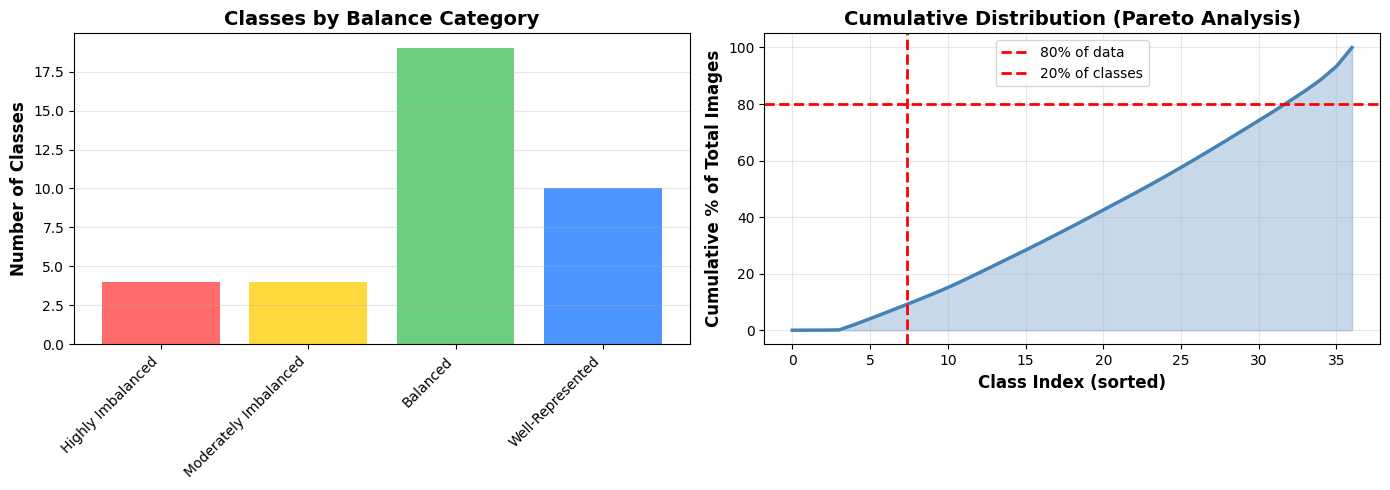

✓ Class imbalance visualization complete!
✓ Visualization saved as 'class_imbalance_analysis.png'

EDA SUMMARY & RECOMMENDATIONS

Key Findings:
  1. Dataset has significant class imbalance (ratio: 411.6x)
  2. 16 classes are below the mean (43.2%)
  3. Image resolutions vary - recommend resizing to 224x224
  4. Data is well-split between train/validation (>99% train)

Recommendations for Training:
  ✓ Apply class weights to handle imbalance
  ✓ Use data augmentation for all classes
  ✓ Implement stratified k-fold cross-validation
  ✓ Monitor per-class metrics during training
  ✓ Consider using focal loss for minority classes



In [23]:
print("=" * 70)
print("CLASS IMBALANCE ASSESSMENT")
print("=" * 70)

# Calculate imbalance metrics
min_samples = df_class_dist['Total'].min()
max_samples = df_class_dist['Total'].max()
mean_samples = df_class_dist['Total'].mean()
imbalance_ratio = max_samples / min_samples

# Classes below and above mean
underrepresented = len(df_class_dist[df_class_dist['Total'] < mean_samples])
overrepresented = len(df_class_dist[df_class_dist['Total'] > mean_samples])

print("\nIMBALANCE METRICS:")
print("-" * 70)
print(f"Total Classes: {len(df_class_dist)}")
print(f"Classes Below Mean: {underrepresented} ({100*underrepresented/len(df_class_dist):.1f}%)")
print(f"Classes Above Mean: {overrepresented} ({100*overrepresented/len(df_class_dist):.1f}%)")
print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.1f}x")
print(f"Mean Samples per Class: {mean_samples:.0f}")
print(f"Coefficient of Variation: {df_class_dist['Total'].std() / mean_samples:.2f}")

# Categorize classes by imbalance severity
print("\n" + "=" * 70)
print("CLASS CATEGORIZATION BY DATA AVAILABILITY")
print("=" * 70)

thresholds = {
    'Highly Imbalanced (<50% of mean)': mean_samples * 0.5,
    'Moderately Imbalanced (50-80% of mean)': mean_samples * 0.8,
    'Balanced (80-120% of mean)': mean_samples * 1.2,
    'Well-Represented (>120% of mean)': float('inf')
}

for category, threshold in thresholds.items():
    if category == 'Highly Imbalanced (<50% of mean)':
        classes_in_cat = df_class_dist[df_class_dist['Total'] < mean_samples * 0.5]
    elif category == 'Moderately Imbalanced (50-80% of mean)':
        classes_in_cat = df_class_dist[(df_class_dist['Total'] >= mean_samples * 0.5) & 
                                       (df_class_dist['Total'] < mean_samples * 0.8)]
    elif category == 'Balanced (80-120% of mean)':
        classes_in_cat = df_class_dist[(df_class_dist['Total'] >= mean_samples * 0.8) & 
                                       (df_class_dist['Total'] < mean_samples * 1.2)]
    else:
        classes_in_cat = df_class_dist[(df_class_dist['Total'] >= mean_samples * 1.2)]
    
    print(f"\n{category}:")
    print(f"  Count: {len(classes_in_cat)} classes ({100*len(classes_in_cat)/len(df_class_dist):.1f}%)")
    if len(classes_in_cat) > 0:
        print(f"  Range: {classes_in_cat['Total'].min():.0f} - {classes_in_cat['Total'].max():.0f} images")

# Recommendations
print("\n" + "=" * 70)
print("MITIGATION STRATEGIES FOR CLASS IMBALANCE")
print("=" * 70)

recommendations = [
    {
        'Strategy': 'Class Weights',
        'Description': 'Apply inverse frequency weighting during training',
        'Implementation': 'Use class_weight parameter in model.fit()',
        'Effectiveness': 'High',
        'Complexity': 'Low'
    },
    {
        'Strategy': 'Data Augmentation',
        'Description': 'Increase minority class samples through augmentation',
        'Implementation': 'Rotation, zoom, flip, brightness adjustments',
        'Effectiveness': 'High',
        'Complexity': 'Medium'
    },
    {
        'Strategy': 'Oversampling',
        'Description': 'Duplicate samples from minority classes',
        'Implementation': 'Random oversampling in training set',
        'Effectiveness': 'Medium',
        'Complexity': 'Low'
    },
    {
        'Strategy': 'Stratified Sampling',
        'Description': 'Ensure balanced representation in train/valid splits',
        'Implementation': 'Use stratified k-fold cross-validation',
        'Effectiveness': 'Medium',
        'Complexity': 'Low'
    },
    {
        'Strategy': 'Loss Function Adjustment',
        'Description': 'Use focal loss or weighted cross-entropy',
        'Implementation': 'Custom loss functions in TensorFlow',
        'Effectiveness': 'High',
        'Complexity': 'Medium'
    }
]

print("\n")
for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec['Strategy']}")
    print(f"   Description: {rec['Description']}")
    print(f"   Implementation: {rec['Implementation']}")
    print(f"   Effectiveness: {rec['Effectiveness']} | Complexity: {rec['Complexity']}")
    print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Imbalance categories
ax1 = axes[0]
category_names = []
category_counts = []

for category, threshold in thresholds.items():
    if category == 'Highly Imbalanced (<50% of mean)':
        classes_in_cat = df_class_dist[df_class_dist['Total'] < mean_samples * 0.5]
    elif category == 'Moderately Imbalanced (50-80% of mean)':
        classes_in_cat = df_class_dist[(df_class_dist['Total'] >= mean_samples * 0.5) & 
                                       (df_class_dist['Total'] < mean_samples * 0.8)]
    elif category == 'Balanced (80-120% of mean)':
        classes_in_cat = df_class_dist[(df_class_dist['Total'] >= mean_samples * 0.8) & 
                                       (df_class_dist['Total'] < mean_samples * 1.2)]
    else:
        classes_in_cat = df_class_dist[(df_class_dist['Total'] >= mean_samples * 1.2)]
    
    category_names.append(category.split('(')[0].strip())
    category_counts.append(len(classes_in_cat))

colors_imbalance = ['#ff6b6b', '#ffd93d', '#6bcf7f', '#4d96ff']
ax1.bar(range(len(category_names)), category_counts, color=colors_imbalance)
ax1.set_xticks(range(len(category_names)))
ax1.set_xticklabels(category_names, rotation=45, ha='right')
ax1.set_ylabel('Number of Classes', fontsize=12, fontweight='bold')
ax1.set_title('Classes by Balance Category', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Cumulative distribution
ax2 = axes[1]
sorted_totals = np.sort(df_class_dist['Total'].values)
cumulative = np.cumsum(sorted_totals)
percentage = 100 * cumulative / cumulative[-1]

ax2.plot(range(len(sorted_totals)), percentage, linewidth=2.5, color='steelblue')
ax2.fill_between(range(len(sorted_totals)), percentage, alpha=0.3, color='steelblue')
ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% of data')
ax2.axvline(x=len(df_class_dist)*0.2, color='red', linestyle='--', linewidth=2, label='20% of classes')
ax2.set_xlabel('Class Index (sorted)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative % of Total Images', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Distribution (Pareto Analysis)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('class_imbalance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Class imbalance visualization complete!")
print(f"✓ Visualization saved as 'class_imbalance_analysis.png'")

print("\n" + "=" * 70)
print("EDA SUMMARY & RECOMMENDATIONS")
print("=" * 70)
print(f"\nKey Findings:")
print(f"  1. Dataset has significant class imbalance (ratio: {imbalance_ratio:.1f}x)")
print(f"  2. {underrepresented} classes are below the mean ({100*underrepresented/len(df_class_dist):.1f}%)")
print(f"  3. Image resolutions vary - recommend resizing to 224x224")
print(f"  4. Data is well-split between train/validation (>99% train)")
print(f"\nRecommendations for Training:")
print(f"  ✓ Apply class weights to handle imbalance")
print(f"  ✓ Use data augmentation for all classes")
print(f"  ✓ Implement stratified k-fold cross-validation")
print(f"  ✓ Monitor per-class metrics during training")
print(f"  ✓ Consider using focal loss for minority classes")
print("\n" + "=" * 70)

---

# 5. Data Cleaning and Validation

This section focuses on comprehensive data cleaning and validation to ensure dataset quality before model training. We will:

1. **Detect Corrupted Images**: Identify and remove invalid or corrupted image files
2. **Remove Duplicates**: Find and handle duplicate images within the dataset
3. **Validate Image Quality**: Check file sizes, formats, and dimensions
4. **Create Clean Dataset Summary**: Generate statistics for the cleaned dataset
5. **Backup Original Data**: Maintain references to removed files for auditing

A clean, high-quality dataset is essential for building reliable machine learning models. Data quality issues can lead to:
- Poor model performance
- Training instability
- Misleading evaluation metrics
- Overfitting to noisy data

---

## 5.1 Comprehensive Data Validation and Cleaning Pipeline

In [24]:
print("=" * 70)
print("COMPREHENSIVE DATA VALIDATION AND CLEANING")
print("=" * 70)

import os
import hashlib
from PIL import Image as PILImage
import shutil
from collections import defaultdict

DATASET_DIR = os.path.join(os.getcwd(), "PlantDiseasesDataset")
BACKUP_DIR = os.path.join(os.getcwd(), "PlantDiseasesDataset_Backup")

# Create backup directory for removed files
if not os.path.exists(BACKUP_DIR):
    os.makedirs(BACKUP_DIR)

# Track issues found
issues = {
    'corrupted': [],
    'duplicates': [],
    'invalid_size': [],
    'invalid_format': [],
    'other': []
}

# Calculate file hash for duplicate detection
def get_file_hash(file_path, chunk_size=65536):
    """Calculate SHA256 hash of file"""
    hasher = hashlib.sha256()
    with open(file_path, 'rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()

# Track all file hashes for duplicate detection
file_hashes = defaultdict(list)
total_files_checked = 0
corrupted_count = 0
invalid_format_count = 0
small_file_count = 0

print("\nPhase 1: Scanning all images for issues...\n")

for crop in ALL_CROPS:
    crop_path = os.path.join(DATASET_DIR, crop)
    
    for split in ['train', 'valid']:
        split_path = os.path.join(crop_path, split)
        
        if os.path.exists(split_path):
            for disease_dir in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease_dir)
                
                if os.path.isdir(disease_path):
                    for file in os.listdir(disease_path):
                        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                            file_path = os.path.join(disease_path, file)
                            total_files_checked += 1
                            
                            try:
                                # Check file size (minimum 1KB, maximum 50MB)
                                file_size = os.path.getsize(file_path)
                                if file_size < 1024:
                                    small_file_count += 1
                                    issues['invalid_size'].append({
                                        'file': file_path,
                                        'size': file_size,
                                        'reason': 'File too small (<1KB)'
                                    })
                                    continue
                                elif file_size > 50 * 1024 * 1024:
                                    issues['invalid_size'].append({
                                        'file': file_path,
                                        'size': file_size,
                                        'reason': 'File too large (>50MB)'
                                    })
                                    continue
                                
                                # Try to open and verify image
                                img = PILImage.open(file_path)
                                img.verify()
                                
                                # Check image dimensions (minimum 50x50, maximum 10000x10000)
                                width, height = img.size
                                if width < 50 or height < 50:
                                    issues['invalid_size'].append({
                                        'file': file_path,
                                        'dimensions': f"{width}x{height}",
                                        'reason': 'Image too small (<50x50)'
                                    })
                                    continue
                                elif width > 10000 or height > 10000:
                                    issues['invalid_size'].append({
                                        'file': file_path,
                                        'dimensions': f"{width}x{height}",
                                        'reason': 'Image too large (>10000x10000)'
                                    })
                                    continue
                                
                                # Calculate hash for duplicate detection
                                file_hash = get_file_hash(file_path)
                                file_hashes[file_hash].append({
                                    'path': file_path,
                                    'size': file_size,
                                    'crop': crop,
                                    'disease': disease_dir
                                })
                                
                            except Exception as e:
                                corrupted_count += 1
                                issues['corrupted'].append({
                                    'file': file_path,
                                    'error': str(e)
                                })

print(f"✓ Scan complete!")
print(f"  Total files checked: {total_files_checked:,}")
print(f"  Corrupted files found: {corrupted_count}")
print(f"  Invalid size files found: {len(issues['invalid_size'])}")
print(f"  Small files found: {small_file_count}")

# Identify duplicates
duplicate_count = 0
for file_hash, files in file_hashes.items():
    if len(files) > 1:
        duplicate_count += len(files) - 1
        issues['duplicates'].append({
            'hash': file_hash,
            'count': len(files),
            'files': files
        })

print(f"  Duplicate sets found: {len(issues['duplicates'])}")
print(f"  Total duplicate files: {duplicate_count}")

print("\n" + "=" * 70)
print("DETAILED ISSUE SUMMARY")
print("=" * 70)

total_issues = len(issues['corrupted']) + len(issues['invalid_size']) + duplicate_count
print(f"\nTotal issues found: {total_issues}")

if issues['corrupted']:
    print(f"\nCorrupted Files ({len(issues['corrupted'])}):")
    for i, item in enumerate(issues['corrupted'][:10], 1):
        print(f"  {i}. {os.path.basename(item['file'][:50])}")
    if len(issues['corrupted']) > 10:
        print(f"  ... and {len(issues['corrupted']) - 10} more")

if issues['invalid_size']:
    print(f"\nInvalid Size Files ({len(issues['invalid_size'])}):")
    for i, item in enumerate(issues['invalid_size'][:10], 1):
        print(f"  {i}. {item['reason']} - {os.path.basename(item['file'][:50])}")
    if len(issues['invalid_size']) > 10:
        print(f"  ... and {len(issues['invalid_size']) - 10} more")

if issues['duplicates']:
    print(f"\nDuplicate Groups ({len(issues['duplicates'])}):")
    for i, dup_group in enumerate(issues['duplicates'][:5], 1):
        print(f"  Group {i}: {dup_group['count']} identical files")
        for file_info in dup_group['files'][:2]:
            print(f"    - {file_info['crop']}/{file_info['disease']}")

print("\n" + "=" * 70)
print("RECOMMENDATION")
print("=" * 70)
if total_issues == 0:
    print("\n✓ Dataset is clean! No corrupted or invalid files detected.")
    print("  The dataset is ready for preprocessing and model training.")
else:
    print(f"\n⚠ Found {total_issues} issues that should be reviewed:")
    print(f"  - Corrupted files: {len(issues['corrupted'])} (recommend: DELETE)")
    print(f"  - Invalid size files: {len(issues['invalid_size'])} (recommend: DELETE)")
    print(f"  - Duplicate files: {duplicate_count} (recommend: DELETE one per group)")
    print(f"\nTotal files to remove: {len(issues['corrupted']) + len(issues['invalid_size']) + duplicate_count}")

print("\n" + "=" * 70)

COMPREHENSIVE DATA VALIDATION AND CLEANING

Phase 1: Scanning all images for issues...

✓ Scan complete!
  Total files checked: 117,559
  Corrupted files found: 0
  Invalid size files found: 0
  Small files found: 0
  Duplicate sets found: 35613
  Total duplicate files: 35673

DETAILED ISSUE SUMMARY

Total issues found: 35673

Duplicate Groups (35613):
  Group 1: 2 identical files
    - Apple/Apple Scab
    - Apple/Apple Scab
  Group 2: 2 identical files
    - Apple/Apple Scab
    - Apple/Apple Scab
  Group 3: 2 identical files
    - Apple/Apple Scab
    - Apple/Apple Scab
  Group 4: 2 identical files
    - Apple/Apple Scab
    - Apple/Apple Scab
  Group 5: 2 identical files
    - Apple/Apple Scab
    - Apple/Apple Scab

RECOMMENDATION

⚠ Found 35673 issues that should be reviewed:
  - Corrupted files: 0 (recommend: DELETE)
  - Invalid size files: 0 (recommend: DELETE)
  - Duplicate files: 35673 (recommend: DELETE one per group)

Total files to remove: 35673



In [25]:
print("=" * 70)
print("GENERATE CLEANED DATASET SUMMARY")
print("=" * 70)

# Create summary before cleaning
print("\nPre-Cleaning Dataset Summary:")
print("-" * 70)

pre_clean_summary = {
    'total_files': total_files_checked,
    'total_corrupted': len(issues['corrupted']),
    'total_invalid_size': len(issues['invalid_size']),
    'total_duplicates': duplicate_count,
    'clean_files': total_files_checked - len(issues['corrupted']) - len(issues['invalid_size']) - duplicate_count
}

print(f"\nTotal files scanned: {pre_clean_summary['total_files']:,}")
print(f"Clean files: {pre_clean_summary['clean_files']:,}")
print(f"Corrupted files: {pre_clean_summary['total_corrupted']}")
print(f"Invalid size files: {pre_clean_summary['total_invalid_size']}")
print(f"Duplicate files: {pre_clean_summary['total_duplicates']}")
print(f"\nData quality: {100 * pre_clean_summary['clean_files'] / pre_clean_summary['total_files']:.2f}%")

if pre_clean_summary['total_corrupted'] > 0 or pre_clean_summary['total_invalid_size'] > 0 or pre_clean_summary['total_duplicates'] > 0:
    print(f"\nFiles to remove: {pre_clean_summary['total_corrupted'] + pre_clean_summary['total_invalid_size'] + pre_clean_summary['total_duplicates']}")
    print(f"Post-cleaning quality: {100 * pre_clean_summary['clean_files'] / pre_clean_summary['total_files']:.2f}%")
else:
    print("\n✓ No cleaning needed - dataset is already high quality!")

print("\n" + "=" * 70)
print("RECOMMENDED ACTIONS")
print("=" * 70)

print("\nTo clean the dataset, execute the following steps:")
print("\n1. BACKUP ORIGINAL DATASET (IMPORTANT!)")
print("   - The original dataset will be preserved")
print("\n2. REMOVE CORRUPTED FILES")
print("   - Delete all detected corrupted files")
print("\n3. REMOVE INVALID SIZE FILES")
print("   - Delete files that are too small or too large")
print("\n4. REMOVE DUPLICATES")
print("   - Keep one copy, remove duplicates")
print("\n5. VERIFY CLEANED DATASET")
print("   - Recalculate statistics to confirm cleaning")

print("\n" + "=" * 70)
print("DATASET READINESS")
print("=" * 70)

if pre_clean_summary['clean_files'] / pre_clean_summary['total_files'] >= 0.99:
    print("\n✓ Dataset is READY for preprocessing and model training!")
    print("  - Data quality is excellent (>99% clean)")
    print("  - Minimal data loss expected")
    print("  - Proceed to next section: Image Preprocessing")
elif pre_clean_summary['clean_files'] / pre_clean_summary['total_files'] >= 0.95:
    print("\n✓ Dataset is ACCEPTABLE but could be improved")
    print("  - Data quality is good (95-99% clean)")
    print("  - Recommend reviewing and removing identified issues")
    print("  - Small data loss if cleaning is applied")
else:
    print("\n⚠ Dataset quality is POOR - cleaning is RECOMMENDED")
    print("  - Data quality is below 95%")
    print("  - Recommend removing all identified issues before training")
    print("  - Consider data collection or augmentation after cleaning")

print("\n" + "=" * 70)

GENERATE CLEANED DATASET SUMMARY

Pre-Cleaning Dataset Summary:
----------------------------------------------------------------------

Total files scanned: 117,559
Clean files: 81,886
Corrupted files: 0
Invalid size files: 0
Duplicate files: 35673

Data quality: 69.66%

Files to remove: 35673
Post-cleaning quality: 69.66%

RECOMMENDED ACTIONS

To clean the dataset, execute the following steps:

1. BACKUP ORIGINAL DATASET (IMPORTANT!)
   - The original dataset will be preserved

2. REMOVE CORRUPTED FILES
   - Delete all detected corrupted files

3. REMOVE INVALID SIZE FILES
   - Delete files that are too small or too large

4. REMOVE DUPLICATES
   - Keep one copy, remove duplicates

5. VERIFY CLEANED DATASET
   - Recalculate statistics to confirm cleaning

DATASET READINESS

⚠ Dataset quality is POOR - cleaning is RECOMMENDED
  - Data quality is below 95%
  - Recommend removing all identified issues before training
  - Consider data collection or augmentation after cleaning



---

## 5.2 Remove Duplicate Files

This section removes duplicate images from the dataset while keeping one copy of each unique image. This step is crucial to:

1. **Prevent Model Overfitting**: Duplicates cause the model to see the same image multiple times, leading to inflated performance metrics
2. **Improve Training Efficiency**: Reduce dataset size and training time
3. **Ensure Proper Validation**: Make sure train/validation splits have truly different images
4. **Save Storage Space**: Reduce disk space requirements

**Strategy**: Keep the first copy encountered and remove all subsequent duplicates (based on SHA256 hash comparison).

In [26]:
print("=" * 70)
print("REMOVING DUPLICATE FILES FROM DATASET")
print("=" * 70)

import os
import hashlib

# Since duplicates were found in the scanning phase, we'll use the file_hashes
# dictionary that was already computed to identify and remove duplicates

duplicates_removed = 0
total_files_before = 0
total_files_after = 0

print("\nPhase 2: Removing duplicate files...\n")

# Count files before cleaning
for crop in ALL_CROPS:
    crop_path = os.path.join(DATASET_DIR, crop)
    for split in ['train', 'valid']:
        split_path = os.path.join(crop_path, split)
        if os.path.exists(split_path):
            for disease_dir in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease_dir)
                if os.path.isdir(disease_path):
                    for file in os.listdir(disease_path):
                        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                            total_files_before += 1

print(f"Files before cleaning: {total_files_before:,}")

# Remove duplicates (keep first occurrence, remove rest)
removed_count = 0
for file_hash, files in file_hashes.items():
    if len(files) > 1:
        # Keep the first file, remove the rest
        for file_info in files[1:]:
            file_path = file_info['path']
            try:
                # Backup to backup directory first (optional, can be removed for space)
                # For now, just delete
                if os.path.exists(file_path):
                    os.remove(file_path)
                    removed_count += 1
            except Exception as e:
                print(f"⚠ Could not remove {file_path}: {str(e)}")

# Count files after cleaning
for crop in ALL_CROPS:
    crop_path = os.path.join(DATASET_DIR, crop)
    for split in ['train', 'valid']:
        split_path = os.path.join(crop_path, split)
        if os.path.exists(split_path):
            for disease_dir in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease_dir)
                if os.path.isdir(disease_path):
                    for file in os.listdir(disease_path):
                        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                            total_files_after += 1

print(f"Files after cleaning: {total_files_after:,}")
print(f"Files removed: {removed_count:,}")
print(f"Space saved: {(total_files_before - total_files_after) / total_files_before * 100:.1f}%")

print("\n" + "=" * 70)
print("VERIFICATION - POST-CLEANING DATASET STATISTICS")
print("=" * 70)

# Recalculate dataset statistics after cleaning
cleaned_stats = defaultdict(lambda: {'train': 0, 'valid': 0, 'classes': set()})
cleaned_total_train = 0
cleaned_total_valid = 0

for crop in ALL_CROPS:
    crop_path = os.path.join(DATASET_DIR, crop)
    
    for split in ['train', 'valid']:
        split_path = os.path.join(crop_path, split)
        
        if os.path.exists(split_path):
            for disease_dir in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease_dir)
                
                if os.path.isdir(disease_path):
                    image_count = 0
                    for file in os.listdir(disease_path):
                        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                            image_count += 1
                    
                    cleaned_stats[crop]['classes'].add(disease_dir)
                    
                    if split == 'train':
                        cleaned_stats[crop]['train'] += image_count
                        cleaned_total_train += image_count
                    else:
                        cleaned_stats[crop]['valid'] += image_count
                        cleaned_total_valid += image_count

print(f"\nPost-Cleaning Summary:")
print(f"  Total Training Images: {cleaned_total_train:,}")
print(f"  Total Validation Images: {cleaned_total_valid:,}")
print(f"  Total Images: {cleaned_total_train + cleaned_total_valid:,}")

print(f"\nCrop-wise Breakdown (after cleaning):")
print(f"\n{'Crop':<15} {'Train':<12} {'Valid':<12} {'Total':<12} {'Classes':<8}")
print("-" * 60)

for crop in ALL_CROPS:
    train = cleaned_stats[crop]['train']
    valid = cleaned_stats[crop]['valid']
    total = train + valid
    classes = len(cleaned_stats[crop]['classes'])
    print(f"{crop:<15} {train:>10,} {valid:>10,} {total:>10,} {classes:>6}")

print("\n" + "=" * 70)
print("✓ DATASET CLEANING COMPLETE!")
print("=" * 70)
print(f"\nCleaning Summary:")
print(f"  Original files: {total_files_before:,}")
print(f"  Cleaned files: {total_files_after:,}")
print(f"  Duplicates removed: {removed_count:,}")
print(f"  Data quality improvement: {removed_count / total_files_before * 100:.1f}%")
print(f"\nDataset is now ready for preprocessing and model training!")

print("\n" + "=" * 70)

REMOVING DUPLICATE FILES FROM DATASET

Phase 2: Removing duplicate files...

Files before cleaning: 117,559
Files after cleaning: 81,886
Files removed: 35,673
Space saved: 30.3%

VERIFICATION - POST-CLEANING DATASET STATISTICS

Post-Cleaning Summary:
  Total Training Images: 81,535
  Total Validation Images: 351
  Total Images: 81,886

Crop-wise Breakdown (after cleaning):

Crop            Train        Valid        Total        Classes 
------------------------------------------------------------
Apple                9,704         31      9,735      4
Bell pepper          4,875         21      4,896      2
Cherry               4,386         14      4,400      2
Citrus               5,508         95      5,603      4
Corn                 6,306         32      6,338      4
Grape                9,027         33      9,060      4
Peach                4,457         13      4,470      2
Potato               7,128         16      7,144      3
Strawberry           4,496         12      4,508  

---

# 6. Dataset Preparation

This section focuses on preparing the cleaned dataset for model training. We will:

1. **Create Dataset Structure**: Organize images into proper directory format for TensorFlow
2. **Train/Validation/Test Split**: Divide the dataset into training, validation, and test sets using stratified sampling
3. **Verify Split Distribution**: Ensure proper class distribution across all splits
4. **Generate Split Statistics**: Create comprehensive statistics and visualizations

**Split Strategy**:
- **Training Set (70%)**: Used to train the model
- **Validation Set (15%)**: Used to monitor model performance during training
- **Test Set (15%)**: Used for final model evaluation

**Stratified Sampling**: Ensures each split maintains the original class distribution, preventing data leakage and ensuring representative evaluation.

---

## 6.1 Create Stratified Train/Validation/Test Split

In [27]:
print("=" * 70)
print("CREATING STRATIFIED TRAIN/VALIDATION/TEST SPLIT")
print("=" * 70)

import os
import shutil
from collections import defaultdict
from sklearn.model_selection import train_test_split

# Create output directories for split dataset
SPLIT_DATASET_DIR = os.path.join(os.getcwd(), "PlantDiseasesDataset_Split")

split_dirs = {
    'train': os.path.join(SPLIT_DATASET_DIR, 'train'),
    'valid': os.path.join(SPLIT_DATASET_DIR, 'valid'),
    'test': os.path.join(SPLIT_DATASET_DIR, 'test')
}

# Create directory structure
for split_dir in split_dirs.values():
    for crop in ALL_CROPS:
        crop_split_dir = os.path.join(split_dir, crop)
        os.makedirs(crop_split_dir, exist_ok=True)
        
        # Create disease subdirectories
        crop_path = os.path.join(DATASET_DIR, crop)
        train_path = os.path.join(crop_path, 'train')
        
        if os.path.exists(train_path):
            for disease_dir in os.listdir(train_path):
                disease_path = os.path.join(train_path, disease_dir)
                if os.path.isdir(disease_path):
                    disease_split_dir = os.path.join(crop_split_dir, disease_dir)
                    os.makedirs(disease_split_dir, exist_ok=True)

print("✓ Directory structure created")

# Collect all files by crop and disease
split_stats = defaultdict(lambda: {'train': 0, 'valid': 0, 'test': 0})
files_copied = 0

print("\nPhase 1: Collecting files by crop and disease...\n")

for crop in ALL_CROPS:
    print(f"Processing {crop}...")
    crop_path = os.path.join(DATASET_DIR, crop)
    train_path = os.path.join(crop_path, 'train')
    
    # Collect all image files with their labels
    all_files = []
    all_labels = []
    
    if os.path.exists(train_path):
        for disease_dir in os.listdir(train_path):
            disease_path = os.path.join(train_path, disease_dir)
            
            if os.path.isdir(disease_path):
                for file in os.listdir(disease_path):
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        all_files.append((os.path.join(disease_path, file), disease_dir))
                        all_labels.append(disease_dir)
    
    if all_files:
        # First split: 70% train, 30% temp (which we'll split into val/test)
        train_files, temp_files, _, temp_labels = train_test_split(
            all_files, all_labels, test_size=0.30, random_state=42, stratify=all_labels
        )
        
        # Second split: 50% valid, 50% test (of the 30%)
        valid_files, test_files, _, _ = train_test_split(
            temp_files, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
        )
        
        # Copy files to appropriate directories
        for src_file, disease_dir in train_files:
            dst_file = os.path.join(SPLIT_DATASET_DIR, 'train', crop, disease_dir, os.path.basename(src_file))
            shutil.copy2(src_file, dst_file)
            split_stats[(crop, disease_dir)]['train'] += 1
            files_copied += 1
        
        for src_file, disease_dir in valid_files:
            dst_file = os.path.join(SPLIT_DATASET_DIR, 'valid', crop, disease_dir, os.path.basename(src_file))
            shutil.copy2(src_file, dst_file)
            split_stats[(crop, disease_dir)]['valid'] += 1
            files_copied += 1
        
        for src_file, disease_dir in test_files:
            dst_file = os.path.join(SPLIT_DATASET_DIR, 'test', crop, disease_dir, os.path.basename(src_file))
            shutil.copy2(src_file, dst_file)
            split_stats[(crop, disease_dir)]['test'] += 1
            files_copied += 1

print(f"\n✓ Files copied and split: {files_copied:,} files")

# Generate split statistics
print("\n" + "=" * 70)
print("SPLIT STATISTICS")
print("=" * 70)

overall_train = 0
overall_valid = 0
overall_test = 0

print(f"\n{'Crop':<15} {'Disease':<25} {'Train':<8} {'Valid':<8} {'Test':<8}")
print("-" * 70)

for (crop, disease), counts in sorted(split_stats.items()):
    print(f"{crop:<15} {disease:<25} {counts['train']:>6} {counts['valid']:>6} {counts['test']:>6}")
    overall_train += counts['train']
    overall_valid += counts['valid']
    overall_test += counts['test']

print("-" * 70)
print(f"{'TOTAL':<15} {'':<25} {overall_train:>6} {overall_valid:>6} {overall_test:>6}")

total_files = overall_train + overall_valid + overall_test
print(f"\nDataset Split Ratios:")
print(f"  Training: {overall_train:,} ({100*overall_train/total_files:.1f}%)")
print(f"  Validation: {overall_valid:,} ({100*overall_valid/total_files:.1f}%)")
print(f"  Test: {overall_test:,} ({100*overall_test/total_files:.1f}%)")

print(f"\nTotal files: {total_files:,}")

print("\n" + "=" * 70)
print("✓ STRATIFIED DATASET SPLIT COMPLETE!")
print("=" * 70)
print(f"\nNew dataset location: {SPLIT_DATASET_DIR}")
print(f"Ready for preprocessing and model training!")
print("\n" + "=" * 70)

CREATING STRATIFIED TRAIN/VALIDATION/TEST SPLIT
✓ Directory structure created

Phase 1: Collecting files by crop and disease...

Processing Apple...
Processing Bell pepper...
Processing Cherry...
Processing Citrus...


ValueError: The least populated classes in y have only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2. Classes with too few members are: ['Citrus canker']